# *DATA SCIENCE ESSENTIALS: HANDS-ON EXAMPLES WITH WIND TURBINE SCADA*
#
#
#
#
# 

# PART 1:  
# DATA EXPLORATION, CLEANING AND DESCRIPTIVE STATISTICS

In the first part of this notebook, we will work with a basic example of turbine SCADA data, and we will explore some of the basic properties of the data. We begin with loading some of the major libraries that we'll use, and load a dataset.

We would normally import libraries closer to the place in the code we use them. But here it makes sense to list (and then import) all packages we'll need - so we have an overview if our environment is set up correctly.

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.plots import plot_convergence

The EDP open data contains 5 wind turbine assets, with about 2 years of data for each asset. Since the data are distributed in multiple files, we will run a script to combine all data in a single dataframe.

Things to consider:
- We suggest to use Asset 0, which has a known generator bearing failure in August 2023, and another suspected one in April 2023 (not labelled). The label data are given in a separate file
- Asset 11 also has a generator bearing failure, but the temperature signals have bad oscillations

In [2]:
import os

data_dir = "../shared/week1/Wednesday-Thursday_fundamental_concepts/Data/Care_to_Compare/Wind Farm A/datasets"
data_files = os.listdir(data_dir)

# COLLECT ALL DATA IN A SINGLE DATAFRAME
AllData = pd.DataFrame()
for ifile in data_files:
    idata = pd.read_csv(os.path.join(data_dir,ifile), sep = ';')
    AllData = pd.concat((AllData,idata))
AllData

,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,...,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg
0,2022-01-01 00:00:00,10,0,train,0,18.0,220.1,6.1,5.2,5.1,...,0.0,-13513.0,0.0,33173.0,-13513.0,11.2,12.2,10.9,0.2,19.0
1,2022-01-01 00:10:00,10,1,train,0,18.0,218.7,4.7,5.7,5.3,...,0.0,-15366.0,0.0,38381.0,-15366.0,11.7,13.1,10.9,0.4,19.0
2,2022-01-01 00:20:00,10,2,train,0,18.0,216.7,2.7,6.2,5.8,...,0.0,-15709.0,0.0,52055.0,-15709.0,12.0,12.8,11.2,0.3,19.0
3,2022-01-01 00:30:00,10,3,train,0,18.0,197.9,-16.1,6.3,6.2,...,0.0,-16444.0,0.0,66365.0,-16444.0,12.2,13.7,11.2,0.7,19.0
4,2022-01-01 00:40:00,10,4,train,0,18.0,217.2,3.2,6.6,6.1,...,0.0,-16344.0,0.0,60980.0,-16344.0,12.6,13.6,11.8,0.4,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54037,2023-06-19 11:00:00,0,54037,prediction,3,28.0,114.8,-7.8,9.8,9.4,...,0.0,-34473.0,0.0,230531.0,-34473.0,14.6,15.1,13.8,0.2,33.0
54038,2023-06-19 11:10:00,0,54038,prediction,3,28.0,127.0,4.4,10.6,10.0,...,0.0,-34761.0,0.0,266018.0,-34761.0,14.7,15.1,13.7,0.2,33.0
54039,2023-06-19 11:20:00,0,54039,prediction,3,29.0,160.4,31.8,10.8,10.3,...,0.0,-35211.0,0.0,275954.0,-35211.0,14.7,15.2,13.1,0.3,33.0
54040,2023-06-19 11:30:00,0,54040,prediction,3,28.0,106.7,-19.4,11.5,10.9,...,0.0,-35783.0,0.0,304990.0,-35783.0,14.8,15.5,14.5,0.1,33.0


The dataframe contains all data now. We can quickly check if we have the five assets represented:

In [3]:
AllData.asset_id.unique()

array([10, 21, 13,  0, 11])

The data channel names are not very informative. We can replace them with the descriptions available in another file:

In [4]:
# LOAD THE FEATURE DESCRIPTION FILE TO RENAME THE FEATURES TO SOME UNDERSTANDABLE NAMES
feature_desc = pd.read_csv("../shared/week1/Wednesday-Thursday_fundamental_concepts/Data/Care_to_Compare/Wind Farm A/feature_description.csv", sep = ';')

# MATCH FEATURE DESCRIPTIONS WITH SENSOR NUMBERS
for isensor in AllData.columns.values:
    if "sensor" in isensor:
        strsplit_i = isensor.split('_')
        sensor_num_i = str(strsplit_i[0] + '_' + strsplit_i[1])
        desci = feature_desc.loc[feature_desc.sensor_name == sensor_num_i,'description'].values[0]
        if len(strsplit_i)>=3:
            sensor_name_i = str(desci + '_' + strsplit_i[2])
        else:
            sensor_name_i = str(desci)
        AllData.rename(columns = {isensor: sensor_name_i}, inplace = True)

In [5]:
AllData.columns.values

array(['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id',
       'Ambient temperature_avg', 'Wind absolute direction_avg',
       'Wind relative direction_avg', 'wind_speed_3_avg',
       'wind_speed_4_avg', 'wind_speed_3_max', 'wind_speed_3_min',
       'wind_speed_3_std', 'Pitch angle_avg', 'Pitch angle_max',
       'Pitch angle_min', 'Pitch angle_std',
       'Temperature in the hub controller_avg',
       'Temperature in the top nacelle controller_avg',
       'Temperature in the choke coils on the VCS-section_avg',
       'Temperature on the VCP-board_avg',
       'Temperature in the VCS cooling water_avg',
       'Temperature in gearbox bearing on high speed shaft_avg',
       'Temperature oil in gearbox_avg',
       'Temperature in generator bearing 2 (Drive End)_avg',
       'Temperature in generator bearing 1 (Non-Drive End)_avg',
       'Temperature inside generator in stator windings phase 1_avg',
       'Temperature inside generator in stator windings phase 2_a

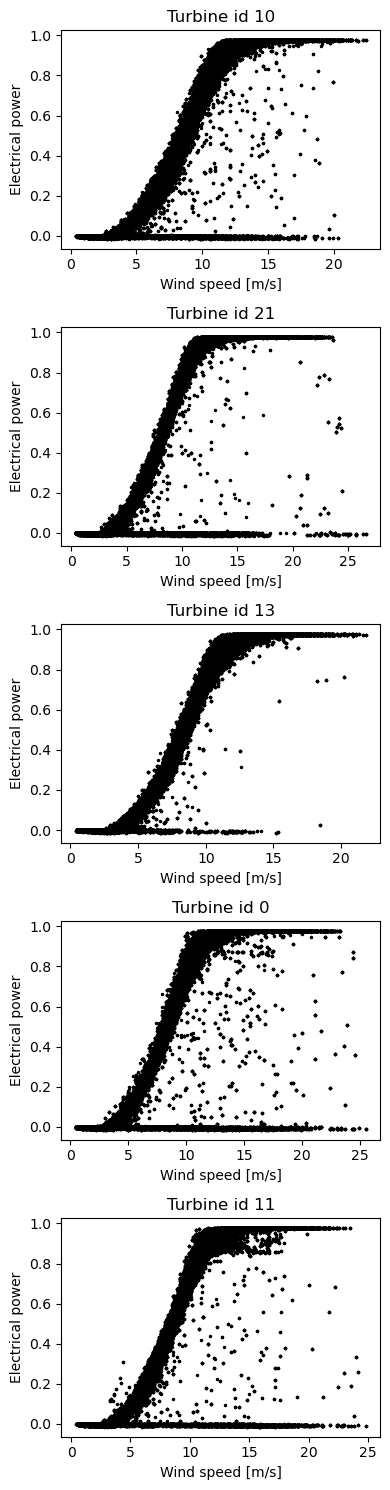

In [6]:
# PLOT EACH TURBINE
figure10 = plt.figure(figsize = (4,15))
for idx,iturbine in enumerate(AllData['asset_id'].unique()):
    figure10.add_subplot(5,1,idx+1)
    plt.plot(AllData.loc[AllData['asset_id']==iturbine,'wind_speed_3_avg'],AllData.loc[AllData['asset_id']==iturbine,'power_30_avg'],'.k',markersize = 3)
    plt.title(str('Turbine id ' + str(iturbine)))
    plt.xlabel('Wind speed [m/s]')
    plt.ylabel('Electrical power')
plt.tight_layout()
    

We want to pick one turbine for analysis (and with changing the "iAsset" variable we can change our mind at any time)

In [7]:
# Pick one turbine for further analysis (we can change at any time)
#iAsset = 10
iAsset = 0
iData = AllData.loc[AllData['asset_id']==iAsset,:].copy()
iData.loc[iData['id']==0,:]

,time_stamp,asset_id,id,train_test,status_type_id,Ambient temperature_avg,Wind absolute direction_avg,Wind relative direction_avg,wind_speed_3_avg,wind_speed_4_avg,...,Reactive power - generator disconnected,Reactive power - generator connected in delta,Reactive power - generator connected in star,Total active power,Total reactive power,Rotor rpm_avg,Rotor rpm_max,Rotor rpm_min,Rotor rpm_std,Temperature in the nose cone_avg
0,2022-10-12 10:20:00,0,0,train,0,17.0,184.0,-10.8,13.2,13.4,...,0.0,-36842.0,0.0,333190.0,-36842.0,14.9,15.7,14.0,0.2,19.0
0,2022-01-01 00:00:00,0,0,train,0,18.0,178.7,-18.6,4.1,4.4,...,0.0,-11991.0,0.0,18831.0,-11991.0,11.1,11.7,10.9,0.1,20.0
0,2022-04-24 15:00:00,0,0,train,4,25.0,317.8,-1.9,3.2,3.2,...,-1086.0,1432.0,0.0,2739.0,346.0,3.6,12.8,1.6,3.5,28.0
0,2022-08-04 06:10:00,0,0,train,0,22.0,302.9,129.4,1.7,1.7,...,-496.0,0.0,0.0,-1280.0,-496.0,0.0,0.0,0.0,0.0,26.0
0,2022-06-07 11:40:00,0,0,train,0,26.0,79.6,-7.2,9.4,9.3,...,0.0,-29207.0,0.0,226986.0,-29207.0,14.5,15.0,13.3,0.3,31.0


Now that we have selected a single turbine, let us delete the "AllData" variable to release memory:

In [8]:
del AllData
del idata

We need to convert the time stamps to a datetime format, so we can easily treat them as time series in pandas. Also, the index is not sorted (a few time steps are misplaced). 

In [9]:
# DATA ARE NOT SORTED AND THE "ID" INDEX IS NOT UNIQUE! 
# LET US SORT "iData" ACCORDING TO TIME
# We need to convert the timestamps to datetime too.
iData['time_stamp'] = pd.to_datetime(iData.loc[:,'time_stamp'])
iData.sort_values(by = 'time_stamp', axis = 0,inplace=True)
iData.reset_index(inplace = True, drop = True)

In [10]:
iData

,time_stamp,asset_id,id,train_test,status_type_id,Ambient temperature_avg,Wind absolute direction_avg,Wind relative direction_avg,wind_speed_3_avg,wind_speed_4_avg,...,Reactive power - generator disconnected,Reactive power - generator connected in delta,Reactive power - generator connected in star,Total active power,Total reactive power,Rotor rpm_avg,Rotor rpm_max,Rotor rpm_min,Rotor rpm_std,Temperature in the nose cone_avg
0,2022-01-01 00:00:00,0,0,train,0,18.0,178.7,-18.6,4.1,4.4,...,0.0,-11991.0,0.0,18831.0,-11991.0,11.1,11.7,10.9,0.1,20.0
1,2022-01-01 00:10:00,0,1,train,0,18.0,191.8,-12.2,4.1,4.3,...,0.0,-14360.0,0.0,15865.0,-14360.0,11.1,11.3,10.9,0.1,20.0
2,2022-01-01 00:20:00,0,2,train,0,18.0,213.8,16.8,4.1,4.4,...,0.0,-15524.0,0.0,17244.0,-15524.0,11.1,11.3,10.9,0.1,20.0
3,2022-01-01 00:30:00,0,3,train,0,18.0,199.3,-4.6,4.4,4.6,...,0.0,-16444.0,0.0,22284.0,-16444.0,11.2,12.4,10.9,0.2,20.0
4,2022-01-01 00:40:00,0,4,train,0,18.0,199.9,-4.0,5.5,5.7,...,0.0,-16353.0,0.0,49587.0,-16353.0,11.4,12.1,10.9,0.3,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272472,2023-10-22 09:40:00,0,53697,prediction,3,21.0,117.8,65.6,1.4,1.4,...,-6.0,0.0,0.0,-485.0,-6.0,0.0,0.0,0.0,0.0,25.0
272473,2023-10-22 09:50:00,0,53698,prediction,3,20.0,88.5,36.3,1.6,1.6,...,-257.0,0.0,0.0,-772.0,-257.0,0.5,1.7,0.0,0.8,25.0
272474,2023-10-22 10:00:00,0,53699,prediction,3,20.0,40.0,-12.2,2.0,2.0,...,-535.0,0.0,0.0,-1065.0,-535.0,1.4,1.7,0.0,0.6,25.0
272475,2023-10-22 10:10:00,0,53700,prediction,3,19.0,34.8,-17.3,1.7,1.7,...,-527.0,0.0,0.0,-1048.0,-527.0,0.1,1.5,0.0,0.3,24.0


# 1.2. Data cleaning (filtering irrelevant or missing data)

Key element to filter on is the *operating status* of the turbine. Often the status may be available as a variable in SCADA. If unavailable, there are several techniques to determine the status:
- Heuristics (if-then-else rules, logic - based on know turbine behavior patterns)
- Clustering (unsupervised approach, "discovering" rules rather than specifying them)
- Variance-based outlier filtering

For the present task, we will directly apply expert-based rules to determine the operating status. We may not need it though, the bearing temperature prediction models can also be trained on non-operational data with similar performance as on fully operational data.

Along with the mean values, the extremes (min or max) will be often useful criteria as certain minima/maxima may occur at the edges of a domain of interest (e.g., minimum rotor/generator rpm is required for power production)

Text(0, 0.5, 'Minimum generator speed [rpm]')

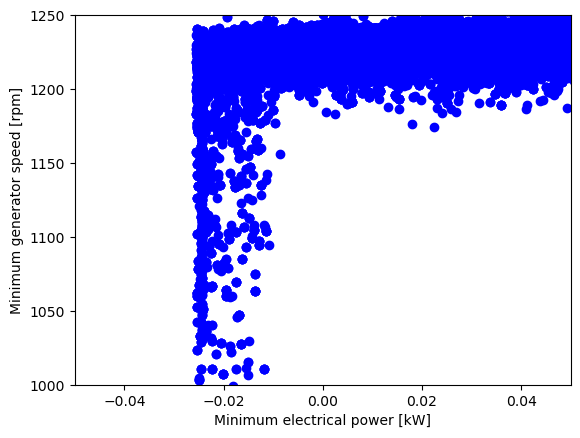

In [11]:
plt.plot(iData['power_30_min'],iData['Generator rpm in latest period_min'],'ob')
plt.gca().set_xlim([-0.05,0.05])
plt.gca().set_ylim([1000,1250])
plt.xlabel('Minimum electrical power [kW]')
plt.ylabel('Minimum generator speed [rpm]')

In [12]:
iData.loc[iData['Generator rpm in latest period_min'] < 1150,'power_30_min'].max()

np.float64(0.1135609756097561)

In [13]:
iProduction_index = iData['power_30_min'] > 0 # Normal operation

In addition to continuous power production, we distinguish three additional states:
- Idling: the turbine is not producing energy, waiting for the wind to pick up above cut-in wind speed - while the rotor is let rotate slowly to avoid potential component (lubrication) damage.
- Parked: the turbine is not producing power and the rotor is stationary
- Transient: a period with at least partial power production operation, but evidence that the turbine has changed operating status.

In [14]:
iIdling_index = (iProduction_index == False) & (iData['power_30_max'] <= 0) & (iData['Generator rpm in latest period_max'] > 0)
iTransient_index = (iProduction_index == False) & (iData['power_30_max'] > 0)
iParked_index = (iProduction_index == False) & (iTransient_index==False) & (iIdling_index == False)

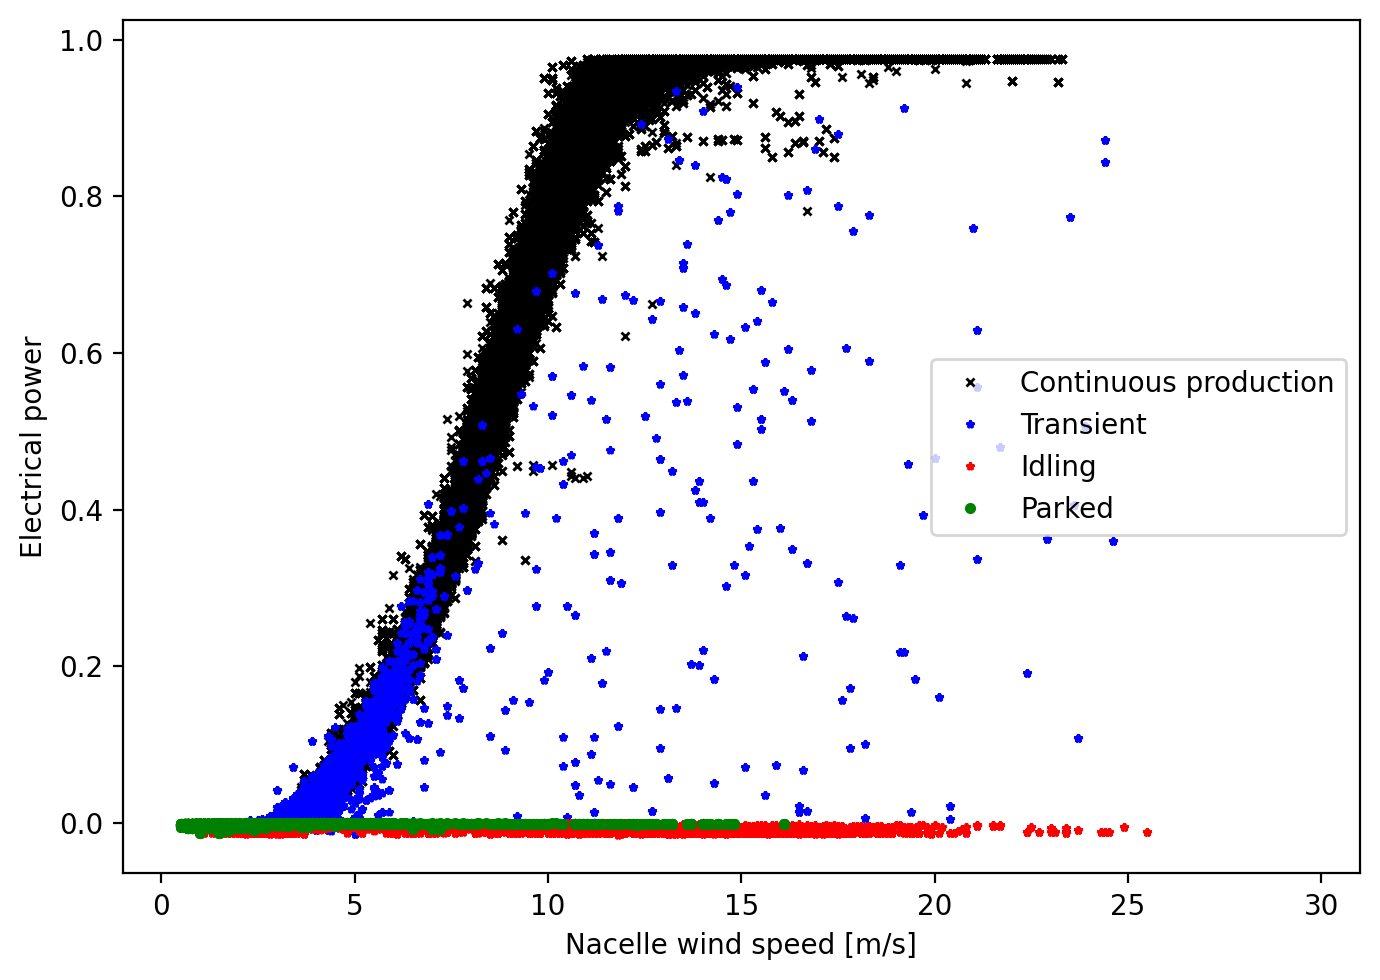

In [15]:
figure11,ax11 = plt.subplots(1,1,figsize = (7,5), dpi = 200)
ax11.plot(iData.loc[iProduction_index,'wind_speed_3_avg'],iData.loc[iProduction_index,'power_30_avg'],'xk',markersize = 3, label = 'Continuous production')
ax11.plot(iData.loc[iTransient_index,'wind_speed_3_avg'],iData.loc[iTransient_index,'power_30_avg'],'*b',markersize = 3, label = 'Transient')
ax11.plot(iData.loc[iIdling_index,'wind_speed_3_avg'],iData.loc[iIdling_index,'power_30_avg'],'*r',markersize = 3, label = 'Idling')
ax11.plot(iData.loc[iParked_index,'wind_speed_3_avg'],iData.loc[iParked_index,'power_30_avg'],'og',markersize = 3, label = 'Parked')
ax11.set_xlabel('Nacelle wind speed [m/s]')
ax11.set_ylabel('Electrical power')
ax11.set_xlim([-1,31])
#ax1.set_ylim([1800, 1810])
ax11.legend()
plt.tight_layout()
plt.show()

In [16]:
print('Production: ' + "{:.2f}".format(100*iProduction_index.sum()/len(iData)) + '%')
print('Idling: ' + "{:.2f}".format(100*iIdling_index.sum()/len(iData)) + '%')
print('Transient: ' + "{:.2f}".format(100*iTransient_index.sum()/len(iData)) + '%')
print('Parked: ' + "{:.2f}".format(100*iParked_index.sum()/len(iData)) + '%')

Production: 58.84%
Idling: 22.49%
Transient: 14.25%
Parked: 4.42%


Finally, we have assigned status flags to all data points. It is useful to have the status flag as an additional column in the dataframe, so that we can filter for different status at any time. 

# Feature selection and model input preparation

We select some candidate features that are likely to produce useful results

In [17]:
CandidateFeatures = ['Temperature in generator bearing 2 (Drive End)_avg',
                     'Temperature in generator bearing 1 (Non-Drive End)_avg',
                     'Ambient temperature_avg',
                     'wind_speed_3_avg',
                     'wind_speed_4_avg', 
                     'wind_speed_3_max',
                     'wind_speed_3_min',
                     'wind_speed_3_std', 
                     'Pitch angle_avg',
                     'Temperature in the hub controller_avg',
                     'Temperature in the top nacelle controller_avg',
                     'Temperature in gearbox bearing on high speed shaft_avg',
                     'Temperature oil in gearbox_avg',
                     'Temperature inside generator in stator windings phase 1_avg',
                     'Temperature inside generator in stator windings phase 2_avg',
                     'Temperature inside generator in stator windings phase 3_avg',
                     'Generator rpm in latest period_avg',
                     'Generator rpm in latest period_max',
                     'Generator rpm in latest period_min',
                     'Generator rpm in latest period_std',
                     'Temperature in the split ring chamber_avg',
                     'power_30_avg',
                     'power_30_max', 
                     'power_30_min', 
                     'power_30_std',
                     'Grid reactive power_avg',
                     'Grid reactive power_max',
                     'Grid reactive power_min', 
                     'Grid reactive power_std',       
                     'Nacelle temperature_avg', 
                     'Temperature in the nose cone_avg']

# 2.1 Correlations and general filter-based selection

In [18]:
iCorr = iData.loc[iProduction_index,CandidateFeatures].corr()

In [19]:
iCorr

,Temperature in generator bearing 2 (Drive End)_avg,Temperature in generator bearing 1 (Non-Drive End)_avg,Ambient temperature_avg,wind_speed_3_avg,wind_speed_4_avg,wind_speed_3_max,wind_speed_3_min,wind_speed_3_std,Pitch angle_avg,Temperature in the hub controller_avg,...,power_30_avg,power_30_max,power_30_min,power_30_std,Grid reactive power_avg,Grid reactive power_max,Grid reactive power_min,Grid reactive power_std,Nacelle temperature_avg,Temperature in the nose cone_avg
Temperature in generator bearing 2 (Drive End)_avg,1.000000,0.908522,0.485408,0.729236,0.716557,0.610909,0.422330,0.678518,0.469438,0.389533,...,0.751983,0.733731,0.697772,0.172518,-0.691888,-0.492300,-0.152113,-0.243037,0.753733,0.380312
Temperature in generator bearing 1 (Non-Drive End)_avg,0.908522,1.000000,0.451443,0.817755,0.805847,0.672785,0.464361,0.770688,0.599522,0.348822,...,0.822742,0.771347,0.794872,0.093551,-0.743577,-0.515287,-0.181574,-0.243974,0.787640,0.341338
Ambient temperature_avg,0.485408,0.451443,1.000000,0.160913,0.121842,0.097102,0.232923,0.099942,0.092844,0.915667,...,0.120485,0.121031,0.102489,0.032126,-0.094462,-0.100378,0.023004,-0.084956,0.850274,0.940117
wind_speed_3_avg,0.729236,0.817755,0.160913,1.000000,0.997452,0.781053,0.575614,0.936432,0.816128,0.073745,...,0.941327,0.860555,0.951883,0.017916,-0.847662,-0.572308,-0.226228,-0.255621,0.520754,0.064365
wind_speed_4_avg,0.716557,0.805847,0.121842,0.997452,1.000000,0.782067,0.565388,0.937984,0.808378,0.038980,...,0.947225,0.869352,0.955613,0.026717,-0.857125,-0.584125,-0.221507,-0.265901,0.488574,0.027545
wind_speed_3_max,0.610909,0.672785,0.097102,0.781053,0.782067,1.000000,0.281292,0.847538,0.547447,0.062638,...,0.782764,0.783752,0.711200,0.247601,-0.747146,-0.521673,-0.174467,-0.249866,0.387516,0.054793
wind_speed_3_min,0.422330,0.464361,0.232923,0.575614,0.565388,0.281292,1.000000,0.383611,0.522692,0.121432,...,0.474880,0.380153,0.560899,-0.204150,-0.401904,-0.283507,-0.095903,-0.131656,0.402497,0.120899
wind_speed_3_std,0.678518,0.770688,0.099942,0.936432,0.937984,0.847538,0.383611,1.000000,0.766414,0.047048,...,0.899379,0.859628,0.861710,0.165556,-0.830461,-0.553141,-0.228455,-0.245661,0.450024,0.040068
Pitch angle_avg,0.469438,0.599522,0.092844,0.816128,0.808378,0.547447,0.522692,0.766414,1.000000,0.038423,...,0.630814,0.450205,0.788150,-0.419938,-0.512734,-0.273123,-0.232919,-0.061642,0.388813,0.034991
Temperature in the hub controller_avg,0.389533,0.348822,0.915667,0.073745,0.038980,0.062638,0.121432,0.047048,0.038423,1.000000,...,0.033926,0.046028,0.008503,0.048807,-0.015950,-0.061664,0.061908,-0.080865,0.742872,0.978363


<Axes: >

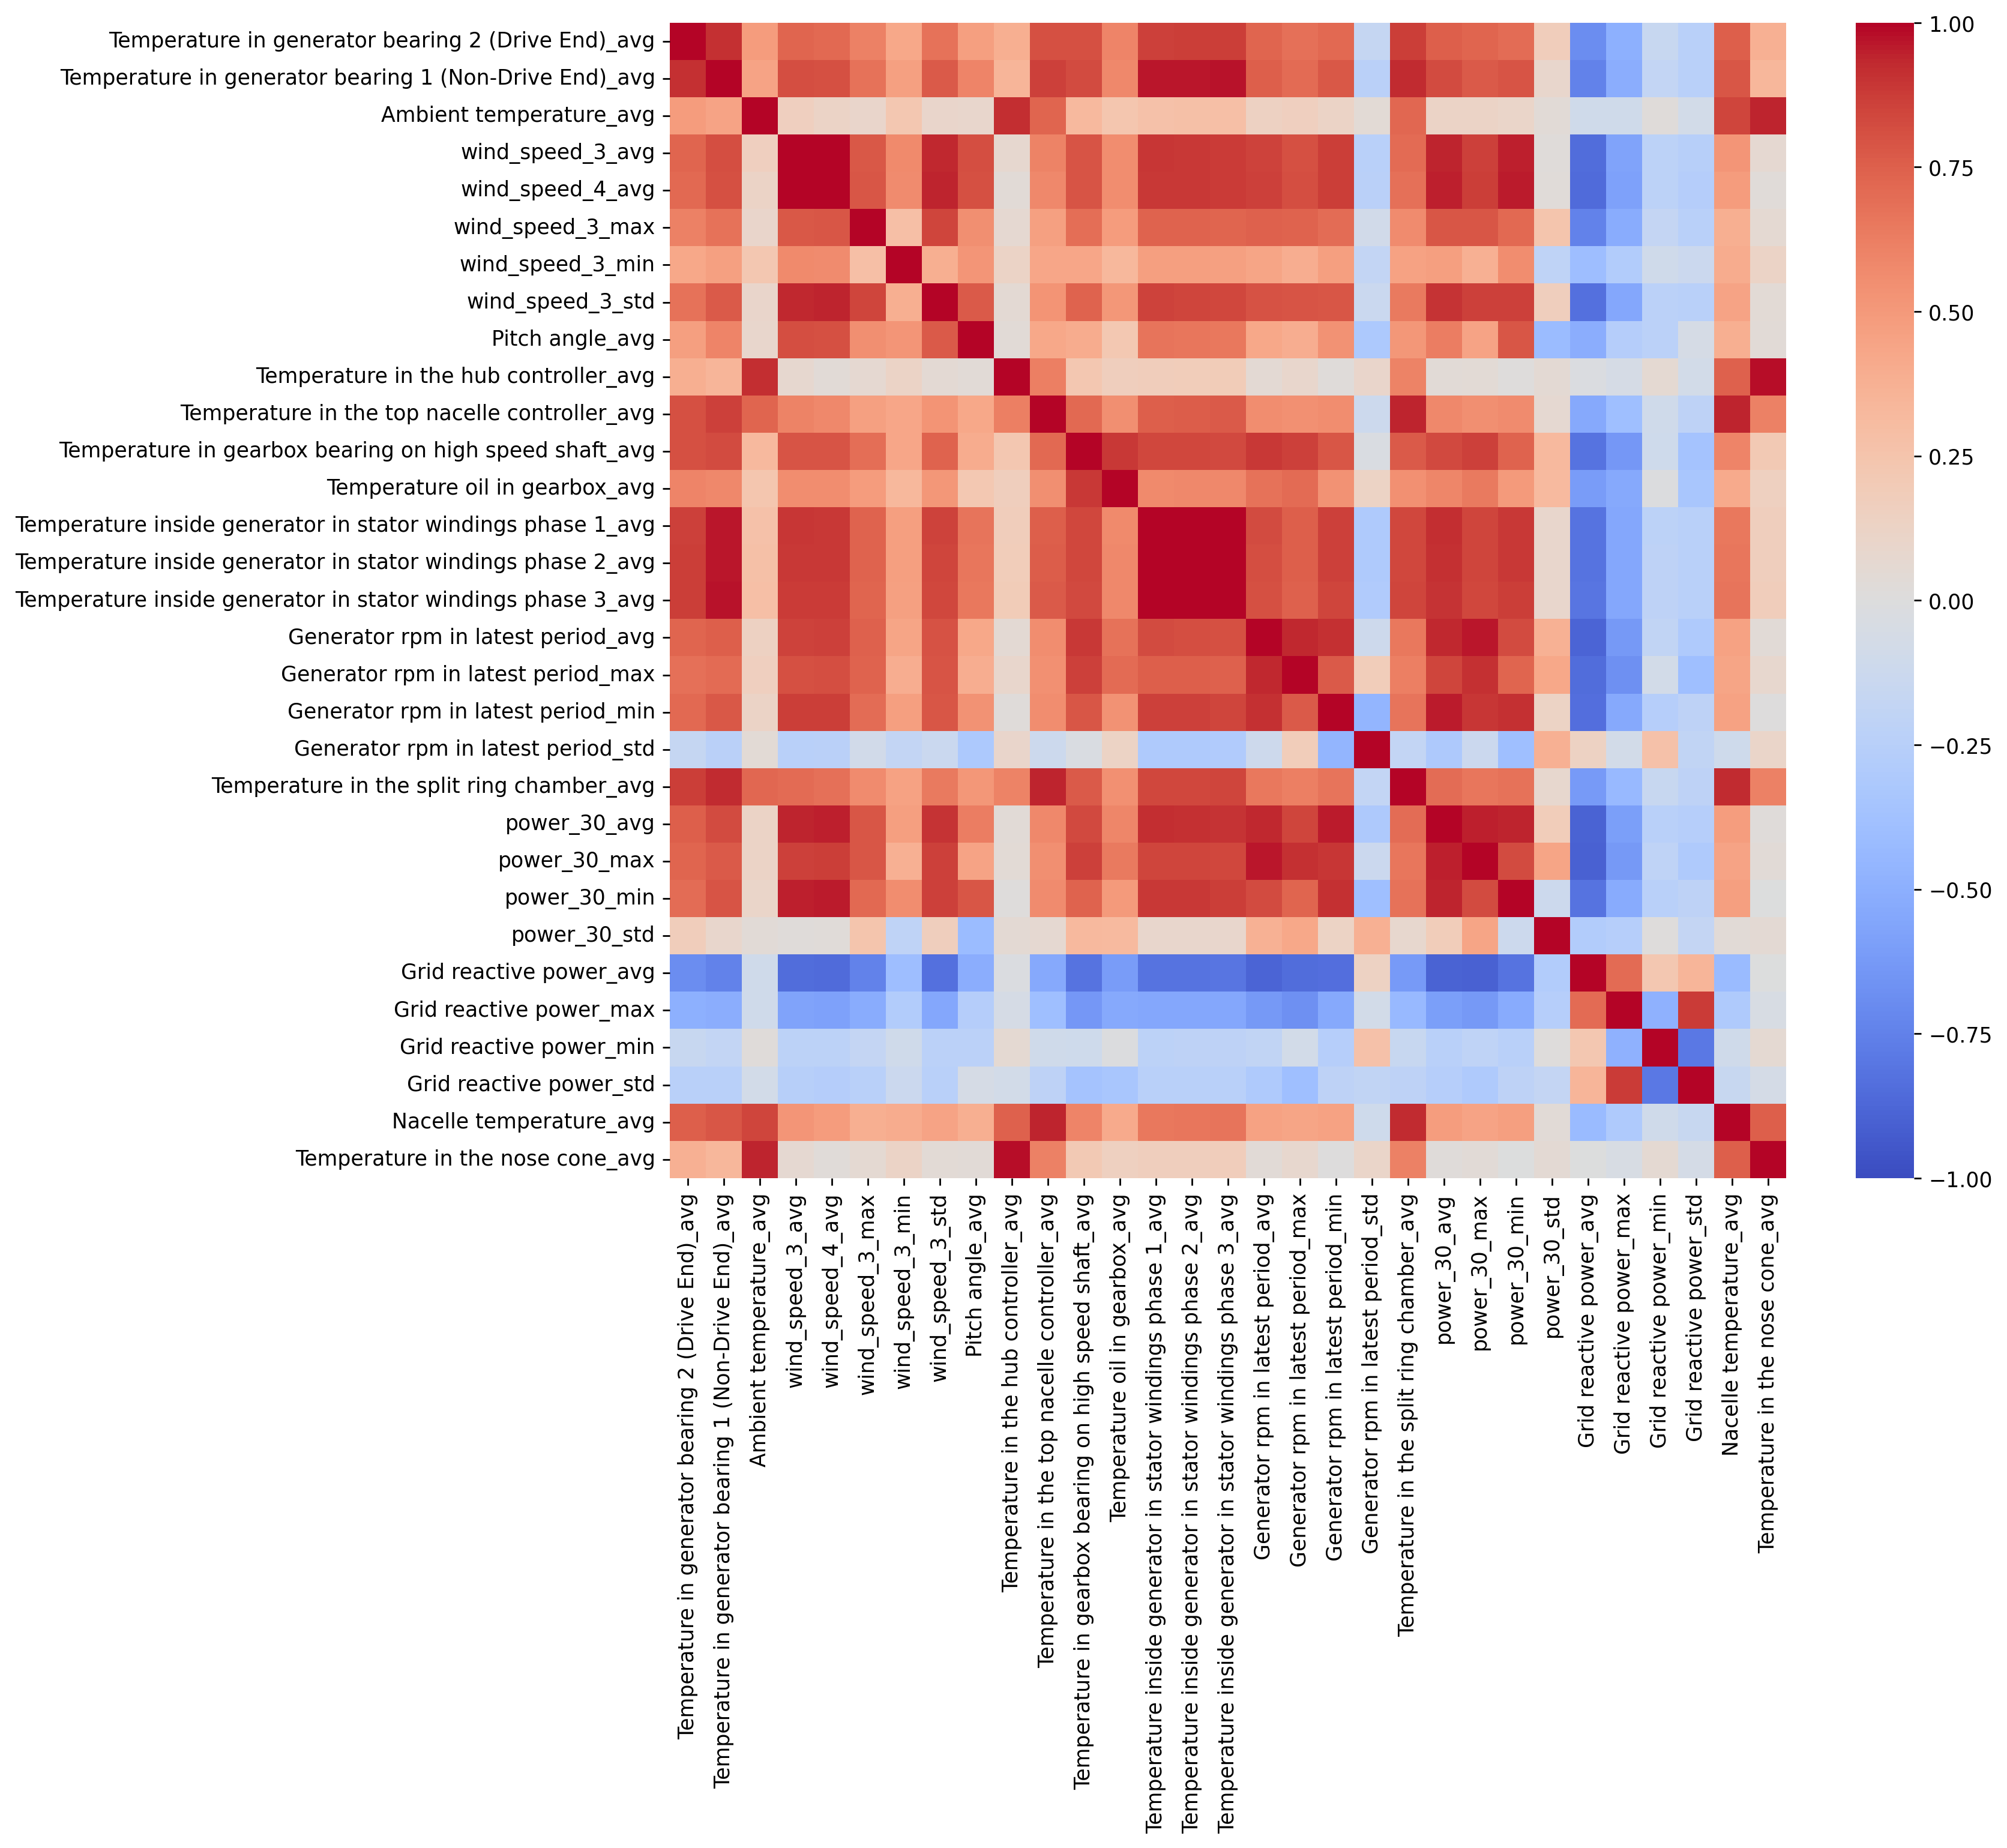

In [20]:
fig1 = plt.figure(figsize = (12,10), dpi = 250)
sns.heatmap(iCorr, cmap = 'coolwarm', vmin = -1, vmax = 1)

We have some promising input data channels for both bearings - but we don't even know which bearing is problematic. Let's see if we can plot the time series around the event and find out what's gone wrong there.

In [21]:
FaultPeriod1 = [pd.to_datetime('06-08-2023  06:10:00',dayfirst = True),pd.to_datetime('20-08-2023  06:10:00',dayfirst = True)] # Asset 0

In [22]:
iData['time_stamp']

0        2022-01-01 00:00:00
1        2022-01-01 00:10:00
2        2022-01-01 00:20:00
3        2022-01-01 00:30:00
4        2022-01-01 00:40:00
                 ...        
272472   2023-10-22 09:40:00
272473   2023-10-22 09:50:00
272474   2023-10-22 10:00:00
272475   2023-10-22 10:10:00
272476   2023-10-22 10:20:00
Name: time_stamp, Length: 272477, dtype: datetime64[ns]

In [23]:
import datetime
PlotPeriod = [FaultPeriod1[0] - datetime.timedelta(days = 30),FaultPeriod1[1]+datetime.timedelta(days = 30)]

In [24]:
iData['time_stamp'].values

array(['2022-01-01T00:00:00.000000000', '2022-01-01T00:10:00.000000000',
       '2022-01-01T00:20:00.000000000', ...,
       '2023-10-22T10:00:00.000000000', '2023-10-22T10:10:00.000000000',
       '2023-10-22T10:20:00.000000000'],
      shape=(272477,), dtype='datetime64[ns]')

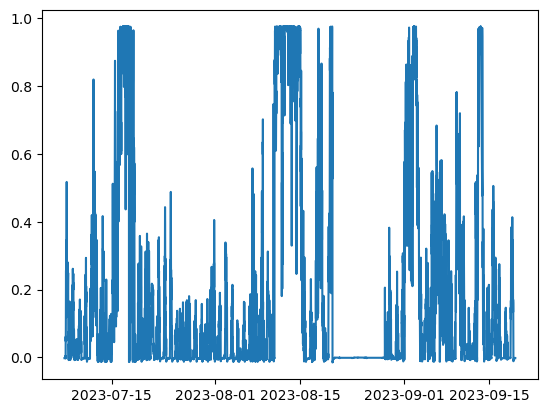

In [25]:
# POWER DURING FAULT PERIOD
plt.plot(iData.loc[(iData['time_stamp'].values>PlotPeriod[0])&(iData['time_stamp'].values<PlotPeriod[1]),'time_stamp'],iData.loc[(iData['time_stamp']>PlotPeriod[0])&(iData['time_stamp']<PlotPeriod[1]),'power_30_avg'])

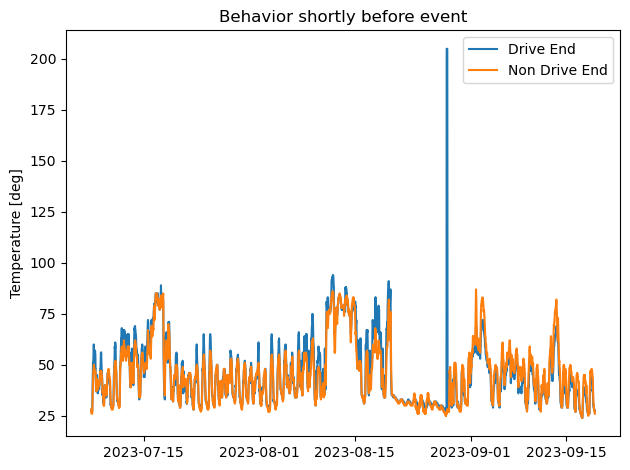

In [26]:
#plt.plot(iData.loc[(iData['time_stamp']>PlotPeriod[0])&(iData['time_stamp']<PlotPeriod[1]),'time_stamp'],iData.loc[(iData['time_stamp']>PlotPeriod[0])&(iData['time_stamp']<PlotPeriod[1]),'power_30_avg'])
plt.plot(iData.loc[(iData['time_stamp'].values > PlotPeriod[0])&(iData['time_stamp'].values < PlotPeriod[1]),'time_stamp'],iData.loc[(iData['time_stamp'].values > PlotPeriod[0])&(iData['time_stamp'].values < PlotPeriod[1]),'Temperature in generator bearing 2 (Drive End)_avg'], label = 'Drive End')
plt.plot(iData.loc[(iData['time_stamp'].values > PlotPeriod[0])&(iData['time_stamp'].values < PlotPeriod[1]),'time_stamp'],iData.loc[(iData['time_stamp'].values > PlotPeriod[0])&(iData['time_stamp'].values < PlotPeriod[1]),'Temperature in generator bearing 1 (Non-Drive End)_avg'], label = 'Non Drive End')
#plt.xlim([FaultPeriod1[0] + datetime.timedelta(days = 10), FaultPeriod1[0] + datetime.timedelta(days = 10, minutes = 120)])
plt.legend()
plt.title('Behavior shortly before event')
plt.ylabel('Temperature [deg]')
plt.tight_layout()
plt.show()

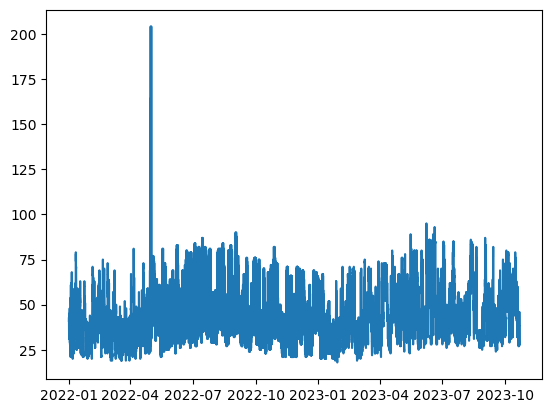

In [27]:
# NON-DRIVE END BEARING (1) OVER THE ENTIRE TIME PERIOD:
plt.plot(iData['time_stamp'],iData['Temperature in generator bearing 1 (Non-Drive End)_avg'])


# Model data preparation

We will try to train three models:

1) NBM for bearing 2 (the drive end), where we have a known event
2) NBM for bearing 1 (the non-drive end), where we have a suspected event
3) NBM for the difference in temperature between bearing 2 and 1

We'll use "B1", "B2" and "B0" codes for the different models. 

In [28]:
InputFeatures_B2 = CandidateFeatures[1:]
TargetFeatures_B2 = CandidateFeatures[0]

NaNindexB2 = (iData[InputFeatures_B2].isna().sum(axis = 1) == 0) & (iData[TargetFeatures_B2].isna() == False)


In order to run model training, we need feature input- and output- pair observations with all features containing valid data. If we are luckly, most observation rows will contain valid data and we can just use those, while eliminating any row with invalid entries. However, if the data gaps are many, one may consider a data filling technique (for example the pandas forward-fill and back-fill methods). The gap filling approach becomes an essential factor when time dependence in the data points needs to be preserved (for example if working with time series models). 

In [29]:
# WE HAVE ONLY TWO NAN DATAPOINTS!
iData.loc[NaNindexB2==False,InputFeatures_B2]

,Temperature in generator bearing 1 (Non-Drive End)_avg,Ambient temperature_avg,wind_speed_3_avg,wind_speed_4_avg,wind_speed_3_max,wind_speed_3_min,wind_speed_3_std,Pitch angle_avg,Temperature in the hub controller_avg,Temperature in the top nacelle controller_avg,...,power_30_avg,power_30_max,power_30_min,power_30_std,Grid reactive power_avg,Grid reactive power_max,Grid reactive power_min,Grid reactive power_std,Nacelle temperature_avg,Temperature in the nose cone_avg
262119,NaN,29.0,4.7,4.7,8.1,1.9,0.9,-0.8,41.0,42.0,...,0.066976,0.136634,0.00839,0.029366,-0.052976,663.8,-928.7,326.6,35.0,36.0
262120,NaN,29.0,4.7,4.7,8.1,1.9,0.9,-0.8,41.0,42.0,...,0.066976,0.136634,0.00839,0.029366,-0.052976,663.8,-928.7,326.6,35.0,36.0


## Feature selection by mutual information scores
Next, we make feature ranking through the mutual information approach. This approach doesn't require data scaling (we can directly apply it on the candidate features, only taking NaNs out.). We may apply on production-only data or all data (with similar results).

In [30]:
MutualInformationScoresB2 = sklearn.feature_selection.mutual_info_regression(iData.loc[(NaNindexB2 & iProduction_index),InputFeatures_B2], iData.loc[(NaNindexB2 & iProduction_index),[TargetFeatures_B2]])

/opt/conda/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [31]:
MuInfFeatureRanks = np.flip(np.argsort(MutualInformationScoresB2))
RankedFeaturesB2_MuInf = [InputFeatures_B2[i] for i in MuInfFeatureRanks]
RankedMuInfScoresB2 = np.flip(np.sort(MutualInformationScoresB2))

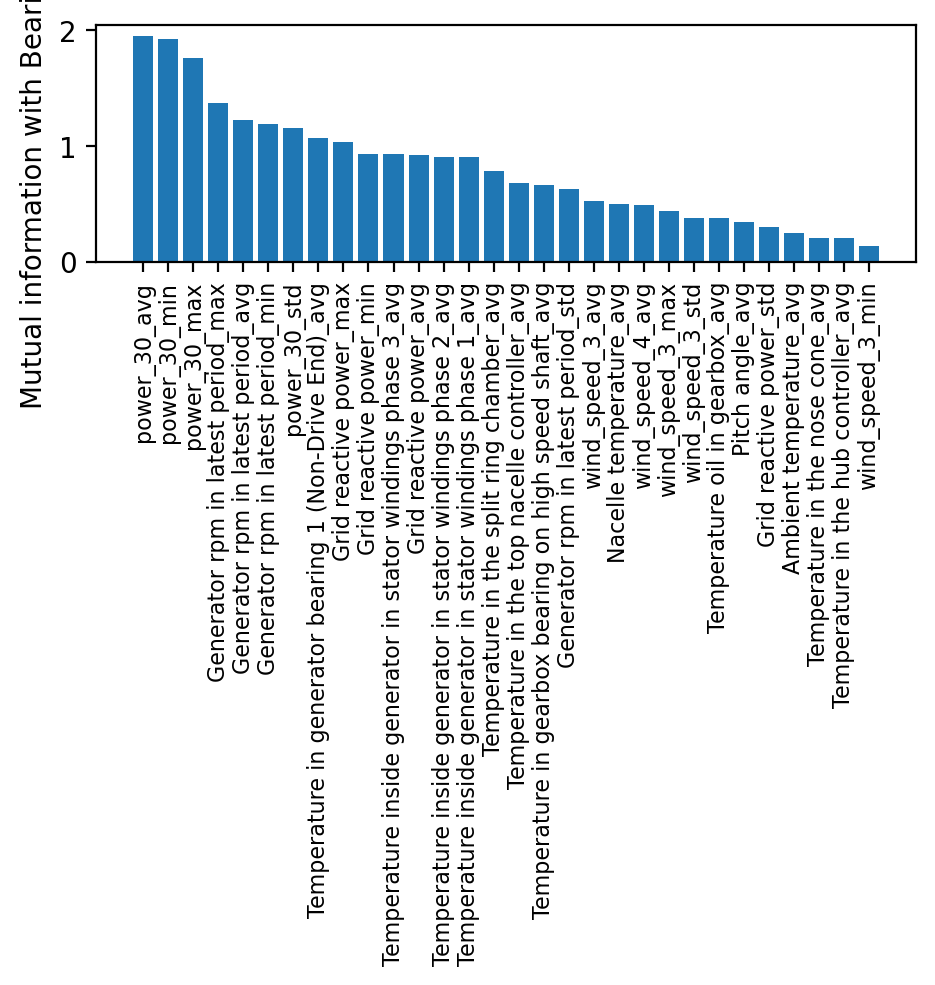

In [32]:
fig5 = plt.figure(figsize = (5,5), dpi = 200)
plt.bar(x = RankedFeaturesB2_MuInf, height=RankedMuInfScoresB2)
plt.xticks(rotation = 90, fontsize = 8)
plt.ylabel('Mutual information with Bearing temp')
plt.tight_layout()
plt.show()

## Feature selection by recursive feature elimination

This modelling approach is a wrapper method which applies a series of model fits and evaluations. In order to apply it, we need to prepare the data for model training. We will therefore move to the next step (model fitting) and show the wrapper methods after we've prepared the model data

# 3 Normality model fitting

# 3.1 Data selection (normal behavior)

We start by selecting what is a "normal behavior" period. We know the failure event timing, so we make sure to exclude this period. 

In [33]:
TrainingPeriodStartB2 = '2022-01-01 00:00:00'
TrainingPeriodEndB2 = '2023-01-01 00:00:00'
TestPeriodStartB2 = '2023-01-01 00:00:00'
TestPeriodEndB2 = '2024-01-01 00:00:00'

TrainingPeriodB2 = (iData['time_stamp'] >= TrainingPeriodStartB2) & (iData['time_stamp'] < TrainingPeriodEndB2)
TestingPeriodB2 = (iData['time_stamp'] >= TestPeriodStartB2) & (iData['time_stamp'] < TestPeriodEndB2)

Data scaling is a common technique when preparing model inputs. It is useful for two reasons: 
1) Some models like Neural Networks will not fit properly unless the data are standardized
2) Having all model variables standardized makes way for more elaborate interpretations of the model properties, such as sensitivity analysis and statistical tests

Notice - we train the scaling functions only once, and use the same functions throughout the text, to keep consistency

In [34]:
XscalerFullB2 = sklearn.preprocessing.StandardScaler()
XscalerFullB2.fit(iData[InputFeatures_B2])
YscalerFullB2 = sklearn.preprocessing.StandardScaler()
YscalerFullB2.fit(iData[[TargetFeatures_B2]])

XtrainFullB2 = XscalerFullB2.transform(iData.loc[(TrainingPeriodB2 & NaNindexB2),InputFeatures_B2])
XtestFullB2 = XscalerFullB2.transform(iData.loc[(TestingPeriodB2 & NaNindexB2),InputFeatures_B2])

YtrainFullB2 = YscalerFullB2.transform(iData.loc[(TrainingPeriodB2 & NaNindexB2),[TargetFeatures_B2]]) # Extra brackets on Target Features needed because it is a 1-D array
YtestFullB2 = YscalerFullB2.transform(iData.loc[(TestingPeriodB2 & NaNindexB2),[TargetFeatures_B2]])

# 3.2 Model choice and fitting

To begin with, we will fit two widely popular model choices:
- Feedforward artificial neural networks (ANNs)
- Random forest regressors

Both modelling approaches are available in sklearn.

In [35]:
# FIT AN ANN

ANNmodelFullB2 = sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(40,40), activation = 'relu', verbose = True)
ANNmodelFullB2.fit(XtrainFullB2, YtrainFullB2.ravel())
ANNmodelFullB2.score(XtestFullB2,YtestFullB2.ravel())

Iteration 1, loss = 0.04608112
Iteration 2, loss = 0.03126736
Iteration 3, loss = 0.03009919
Iteration 4, loss = 0.02922179
Iteration 5, loss = 0.02855284
Iteration 6, loss = 0.02802329
Iteration 7, loss = 0.02739580
Iteration 8, loss = 0.02686763
Iteration 9, loss = 0.02641429
Iteration 10, loss = 0.02601693
Iteration 11, loss = 0.02573714
Iteration 12, loss = 0.02531465
Iteration 13, loss = 0.02503188
Iteration 14, loss = 0.02467480
Iteration 15, loss = 0.02445859
Iteration 16, loss = 0.02407139
Iteration 17, loss = 0.02394859
Iteration 18, loss = 0.02375229
Iteration 19, loss = 0.02351369
Iteration 20, loss = 0.02332041
Iteration 21, loss = 0.02320331
Iteration 22, loss = 0.02291965
Iteration 23, loss = 0.02289358
Iteration 24, loss = 0.02267290
Iteration 25, loss = 0.02260276
Iteration 26, loss = 0.02242247
Iteration 27, loss = 0.02229357
Iteration 28, loss = 0.02224705
Iteration 29, loss = 0.02202180
Iteration 30, loss = 0.02192322
Iteration 31, loss = 0.02191231
Iteration 32, los

0.8657837407598651

In [36]:
# RANDOM FOREST MODEL - SEEMS TO BREAK THE KERNEL IN THE JUPYTER CLASSROOM.
# UNCOMMENT TO TEST IN ANOTHER ENVIRONMENT
#RFmodelFullB2 = sklearn.ensemble.RandomForestRegressor(n_estimators=100)
#RFmodelFullB2.fit(XtrainFullB2, YtrainFullB2)
#RFmodelFullB2.score(XtestFullB2,YtestFullB2.ravel())

We now select a (somewhat arbitrary) reduced feature set which we'll use for testing other feature selection methods (which are slower especially when applied on many features).

In [37]:
FeatureSubsetB2 = [  'Temperature in generator bearing 1 (Non-Drive End)_avg',
                     'Ambient temperature_avg',
                     'wind_speed_3_avg',
                     'wind_speed_3_std', 
                     'Temperature in the top nacelle controller_avg',
                     'Temperature in gearbox bearing on high speed shaft_avg',
                     'Temperature inside generator in stator windings phase 3_avg',
                     'Generator rpm in latest period_avg',
                     'Generator rpm in latest period_max',
                     'Generator rpm in latest period_min',
                     'Generator rpm in latest period_std',
                     'Temperature in the split ring chamber_avg',
                     'power_30_avg',
                     'power_30_max', 
                     'power_30_min', 
                     'power_30_std',
                     'Grid reactive power_avg',
                     'Nacelle temperature_avg']

In [38]:
XscalerB2 = sklearn.preprocessing.StandardScaler()
XscalerB2.fit(iData[FeatureSubsetB2])
YscalerB2 = sklearn.preprocessing.StandardScaler()
YscalerB2.fit(iData[[TargetFeatures_B2]])

XtrainB2 = XscalerB2.transform(iData.loc[(TrainingPeriodB2 & NaNindexB2),FeatureSubsetB2])
XtestB2 = XscalerB2.transform(iData.loc[(TestingPeriodB2 & NaNindexB2),FeatureSubsetB2])

YtrainB2 = YscalerB2.transform(iData.loc[(TrainingPeriodB2 & NaNindexB2),[TargetFeatures_B2]]) # Extra brackets on Target Features needed because it is a 1-D array
YtestB2 = YscalerB2.transform(iData.loc[(TestingPeriodB2 & NaNindexB2),[TargetFeatures_B2]])

In [39]:
ANNmodelB2 = sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(40,40), activation = 'relu', verbose = True)
ANNmodelB2.fit(XtrainB2, YtrainB2.ravel())
ANNmodelB2.score(XtestB2,YtestB2.ravel())

Iteration 1, loss = 0.04264757
Iteration 2, loss = 0.03093215
Iteration 3, loss = 0.03017725
Iteration 4, loss = 0.02970733
Iteration 5, loss = 0.02937893
Iteration 6, loss = 0.02905369
Iteration 7, loss = 0.02871952
Iteration 8, loss = 0.02822411
Iteration 9, loss = 0.02799506
Iteration 10, loss = 0.02754272
Iteration 11, loss = 0.02733589
Iteration 12, loss = 0.02692705
Iteration 13, loss = 0.02662677
Iteration 14, loss = 0.02638445
Iteration 15, loss = 0.02613356
Iteration 16, loss = 0.02598628
Iteration 17, loss = 0.02567682
Iteration 18, loss = 0.02552483
Iteration 19, loss = 0.02540351
Iteration 20, loss = 0.02530115
Iteration 21, loss = 0.02511646
Iteration 22, loss = 0.02498437
Iteration 23, loss = 0.02494294
Iteration 24, loss = 0.02479192
Iteration 25, loss = 0.02479986
Iteration 26, loss = 0.02463816
Iteration 27, loss = 0.02454167
Iteration 28, loss = 0.02446274
Iteration 29, loss = 0.02450300
Iteration 30, loss = 0.02430034
Iteration 31, loss = 0.02425220
Iteration 32, los

0.8774256994637475

## Feature selection by recursive feature elimination

In [40]:
min_features_to_select = 1
rfe_modelB2 = sklearn.feature_selection.RFE(estimator = sklearn.ensemble.RandomForestRegressor(),
                                          step = 1,
                                          n_features_to_select = min_features_to_select,
                                          verbose = True)
rfecv_modelB2 = sklearn.feature_selection.RFECV(estimator = sklearn.ensemble.RandomForestRegressor(),
                                          step = 1,
                                          min_features_to_select = min_features_to_select)



In [41]:
rfe_modelB2.fit(XtrainB2,YtrainB2.ravel())

Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.


,estimator,RandomForestRegressor()
,n_features_to_select,1
,step,1
,verbose,True
,importance_getter,'auto'
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [42]:
# THIS IS SLOW - ONLY USE IF YOU HAVE MORE TIME!
#rfecv_model.fit(XtrainB2,YtrainB2.ravel())

In [43]:
print(rfe_modelB2.ranking_)

[ 2  4 18 17  8 11  1  3 15 14 10  7 16 12  9  6  5 13]


Now we've obtained the feature ranking order - we can train models sequentially, starting from the most important feature and looking at the results when we add (less important) features

In [44]:
ANNscoresB2 = np.zeros(len(rfe_modelB2.ranking_))
B2ranks = np.flip(rfe_modelB2.ranking_)
ranked_features_B2 = [FeatureSubsetB2[i-1] for i in B2ranks]

for i in range(len(ANNscoresB2)):
    print(i)
    ANNi = sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(40,40), activation='relu')
    inputsi = np.asarray(B2ranks[:(i+1)],dtype = int)-1
    ANNi.fit(XtrainB2[:,inputsi],YtrainB2.ravel())
    ANNscoresB2[i] = ANNi.score(XtestB2[:,inputsi],YtestB2.ravel())

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17


Text(0, 0.5, 'ANN R^2 score')

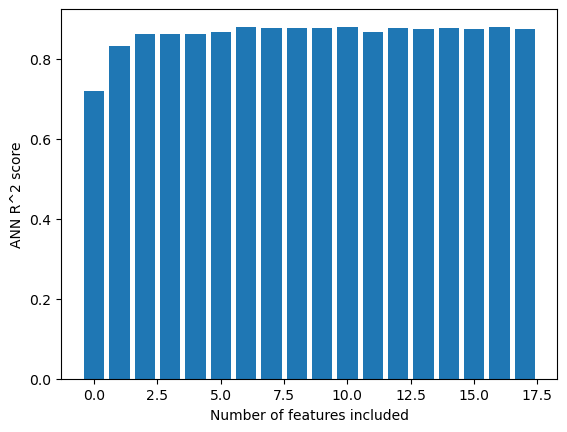

In [61]:
plt.bar(np.arange(len(ANNscoresB2)), ANNscoresB2)
plt.xlabel('Number of features included')
plt.ylabel('ANN R^2 score')

We can also apply a PCA (Principle Component Analysis), in this case just to illustrate the method (and also see that 6 components could provide similar performance as 18 features):

In [45]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(XtrainFullB2)
print(np.cumsum(pca.explained_variance_ratio_))

[0.54719851 0.68361036 0.78519542 0.84581259 0.88361915 0.90997085
 0.93272051 0.94867292 0.96232197 0.9699611  0.97639092 0.98171896
 0.98602421 0.98968028 0.99155787 0.99341359 0.9949421  0.99602771
 0.99692027 0.99757542 0.99806807 0.99851458 0.99891219 0.9992538
 0.99953802 0.99976914 0.99994907 0.99999136 0.99999689 1.        ]


In [46]:
ANN_PCA = sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(40,40), activation = 'relu',verbose = False)
ANN_PCA.fit(pca.transform(XtrainFullB2)[:,:6],YtrainFullB2.ravel())
ANN_PCA.score(pca.transform(XtestFullB2)[:,:6],YtestFullB2.ravel())

0.871182168577812

Example of looking at autocorrelation (we won't use it, so it is just to see how it's done):

Text(0.5, 1.0, 'Generator bearing temp autocorrelation')

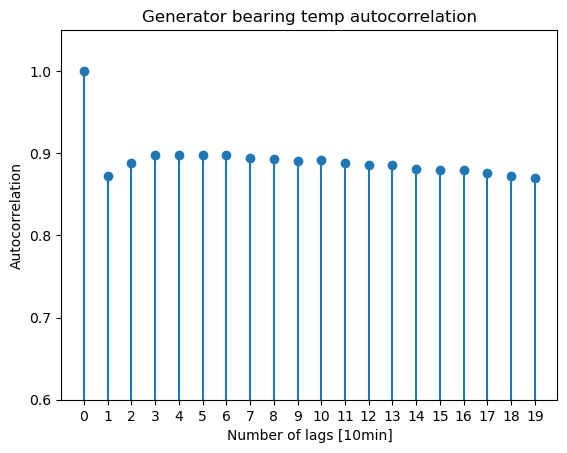

In [47]:
# DO WE NEED TO CONSIDER CORRELATION?
Nlags = 20
import scipy
iFeature = 0
iSeries = (iData.loc[:,InputFeatures_B2[iFeature]].dropna() - iData.loc[:,InputFeatures_B2[iFeature]].dropna().mean())/iData.loc[:,InputFeatures_B2[iFeature]].dropna().std()
#iSeries = XtrainFullB2[:,iFeature] - np.mean(XtrainFullB2[:,iFeature])
Ycorr1 = scipy.signal.correlate(iSeries,iSeries)
Ycorr1 = Ycorr1/Ycorr1[int(len(Ycorr1)/2)]
Ycorr1 = Ycorr1[int(len(Ycorr1)/2):int(len(Ycorr1)/2)+Nlags]
plt.gca().stem(np.arange(Nlags),Ycorr1)
plt.ylim([0.6, 1.05])
plt.xticks(np.arange(Nlags))
plt.xlabel('Number of lags [10min]')
plt.ylabel('Autocorrelation')
plt.title('Generator bearing temp autocorrelation')
#plt.title('Ambient temperature autocorrelation')
#plt.title('10-minute average wind speed autocorrelation')

## Hyperparameter tuning

We have already applied the mutual information criterion. Also, we saw that the recursive feature elimination with the underlying random forest model is quite slow. So, this time we try the sequential feature elimination - which can be done with a Neural Network as underlying model (a bit faster - but on the other hand the sequential feature selection algorithm requires fitting more models, so it will still take over an hour to fit).

In [48]:
# SEQUENTIAL FEATURE SELECTOR - BE AWARE IT TAKES OVER AN HOUR! UNCOMMENT IN ORDER TO USE
'''
from sklearn.feature_selection import SequentialFeatureSelector
sfs = SequentialFeatureSelector(sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(20,20),activation = 'relu'), n_features_to_select=6)
sfs.fit(XtrainB2, YtrainB2.ravel())
SelectedFeaturesMask = sfs.get_support()
print(SelectedFeaturesMask)
SelectedFeatures = []
for i,iFeature in enumerate(FeatureSubsetB2): 
    if SelectedFeaturesMask[i] == True:
        SelectedFeatures.append(iFeature)
print(SelectedFeatures)
'''

"\nfrom sklearn.feature_selection import SequentialFeatureSelector\nsfs = SequentialFeatureSelector(sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(20,20),activation = 'relu'), n_features_to_select=6)\nsfs.fit(XtrainB2, YtrainB2.ravel())\nSelectedFeaturesMask = sfs.get_support()\nprint(SelectedFeaturesMask)\nSelectedFeatures = []\nfor i,iFeature in enumerate(FeatureSubsetB2): \n    if SelectedFeaturesMask[i] == True:\n        SelectedFeatures.append(iFeature)\nprint(SelectedFeatures)\n"

In [64]:
# FINAL FEATURES SELECTION: SEVERAL OPTIONS: 
# 1) Just take the top features from the mutual information approach (faster)
#InputFeatures_B2Final = [RankedFeaturesB2_MuInf[i] for i in range(len(RankedFeaturesB2_MuInf))] # all features
# 2) The top ranked features from the recursive feature elimination
InputFeatures_B2Final = [ranked_features_B2[i] for i in range(7)] # top 7 features
# 3) Take the features selected from the sequential feature selector (slower)
#InputFeatures_B2Final = SelectedFeatures



In [65]:
InputFeatures_B2Final

['power_30_avg',
 'Temperature in the top nacelle controller_avg',
 'Temperature in gearbox bearing on high speed shaft_avg',
 'Generator rpm in latest period_max',
 'Temperature in the split ring chamber_avg',
 'power_30_std',
 'Temperature inside generator in stator windings phase 3_avg']

In [67]:
# FINAL LIST OF FEATURES

XscalerB2Final = sklearn.preprocessing.StandardScaler()
XscalerB2Final.fit(iData[InputFeatures_B2Final])
YscalerB2Final = sklearn.preprocessing.StandardScaler()
YscalerB2Final.fit(iData[[TargetFeatures_B2]])

XtrainB2Final = XscalerB2Final.transform(iData.loc[(TrainingPeriodB2 & NaNindexB2),InputFeatures_B2Final])
XtestB2Final = XscalerB2Final.transform(iData.loc[(TestingPeriodB2 & NaNindexB2),InputFeatures_B2Final])

YtrainB2Final = YscalerB2Final.transform(iData.loc[(TrainingPeriodB2 & NaNindexB2),[TargetFeatures_B2]]) # Extra brackets on Target Features needed because it is a 1-D array
YtestB2Final = YscalerB2Final.transform(iData.loc[(TestingPeriodB2 & NaNindexB2),[TargetFeatures_B2]])

In [68]:
ANN_B2 = sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(40,40),activation = 'relu')
ANN_B2.fit(XtrainB2Final,YtrainB2Final.ravel())
ANN_B2.score(XtestB2Final,YtestB2Final)

0.88105274909017

In [69]:
# EVALUATE THE NBM OVER THE ENTIRE DATASET (FOR "POWER OK" STATUS)

NBMinputvalidB2 = iData[InputFeatures_B2Final].isna().sum(axis = 1)==0

NBM_B2_temp = YscalerB2Final.inverse_transform(ANN_B2.predict(XscalerB2Final.transform(iData.loc[NBMinputvalidB2,InputFeatures_B2Final])).reshape(-1, 1))
#NBMpower[NBMpower < 0] = 0

iData["NBM_B2_temp"] = np.nan
iData.loc[NBMinputvalidB2,"NBM_B2_temp"] = NBM_B2_temp
NBM_B2_residuals = iData.loc[NBMinputvalidB2,"NBM_B2_temp"] - iData.loc[NBMinputvalidB2,'Temperature in generator bearing 2 (Drive End)_avg']

iData["NBM_B2_temp_residual"] = 0.0
iData.loc[NBMinputvalidB2,"NBM_B2_temp_residual"] = NBM_B2_residuals

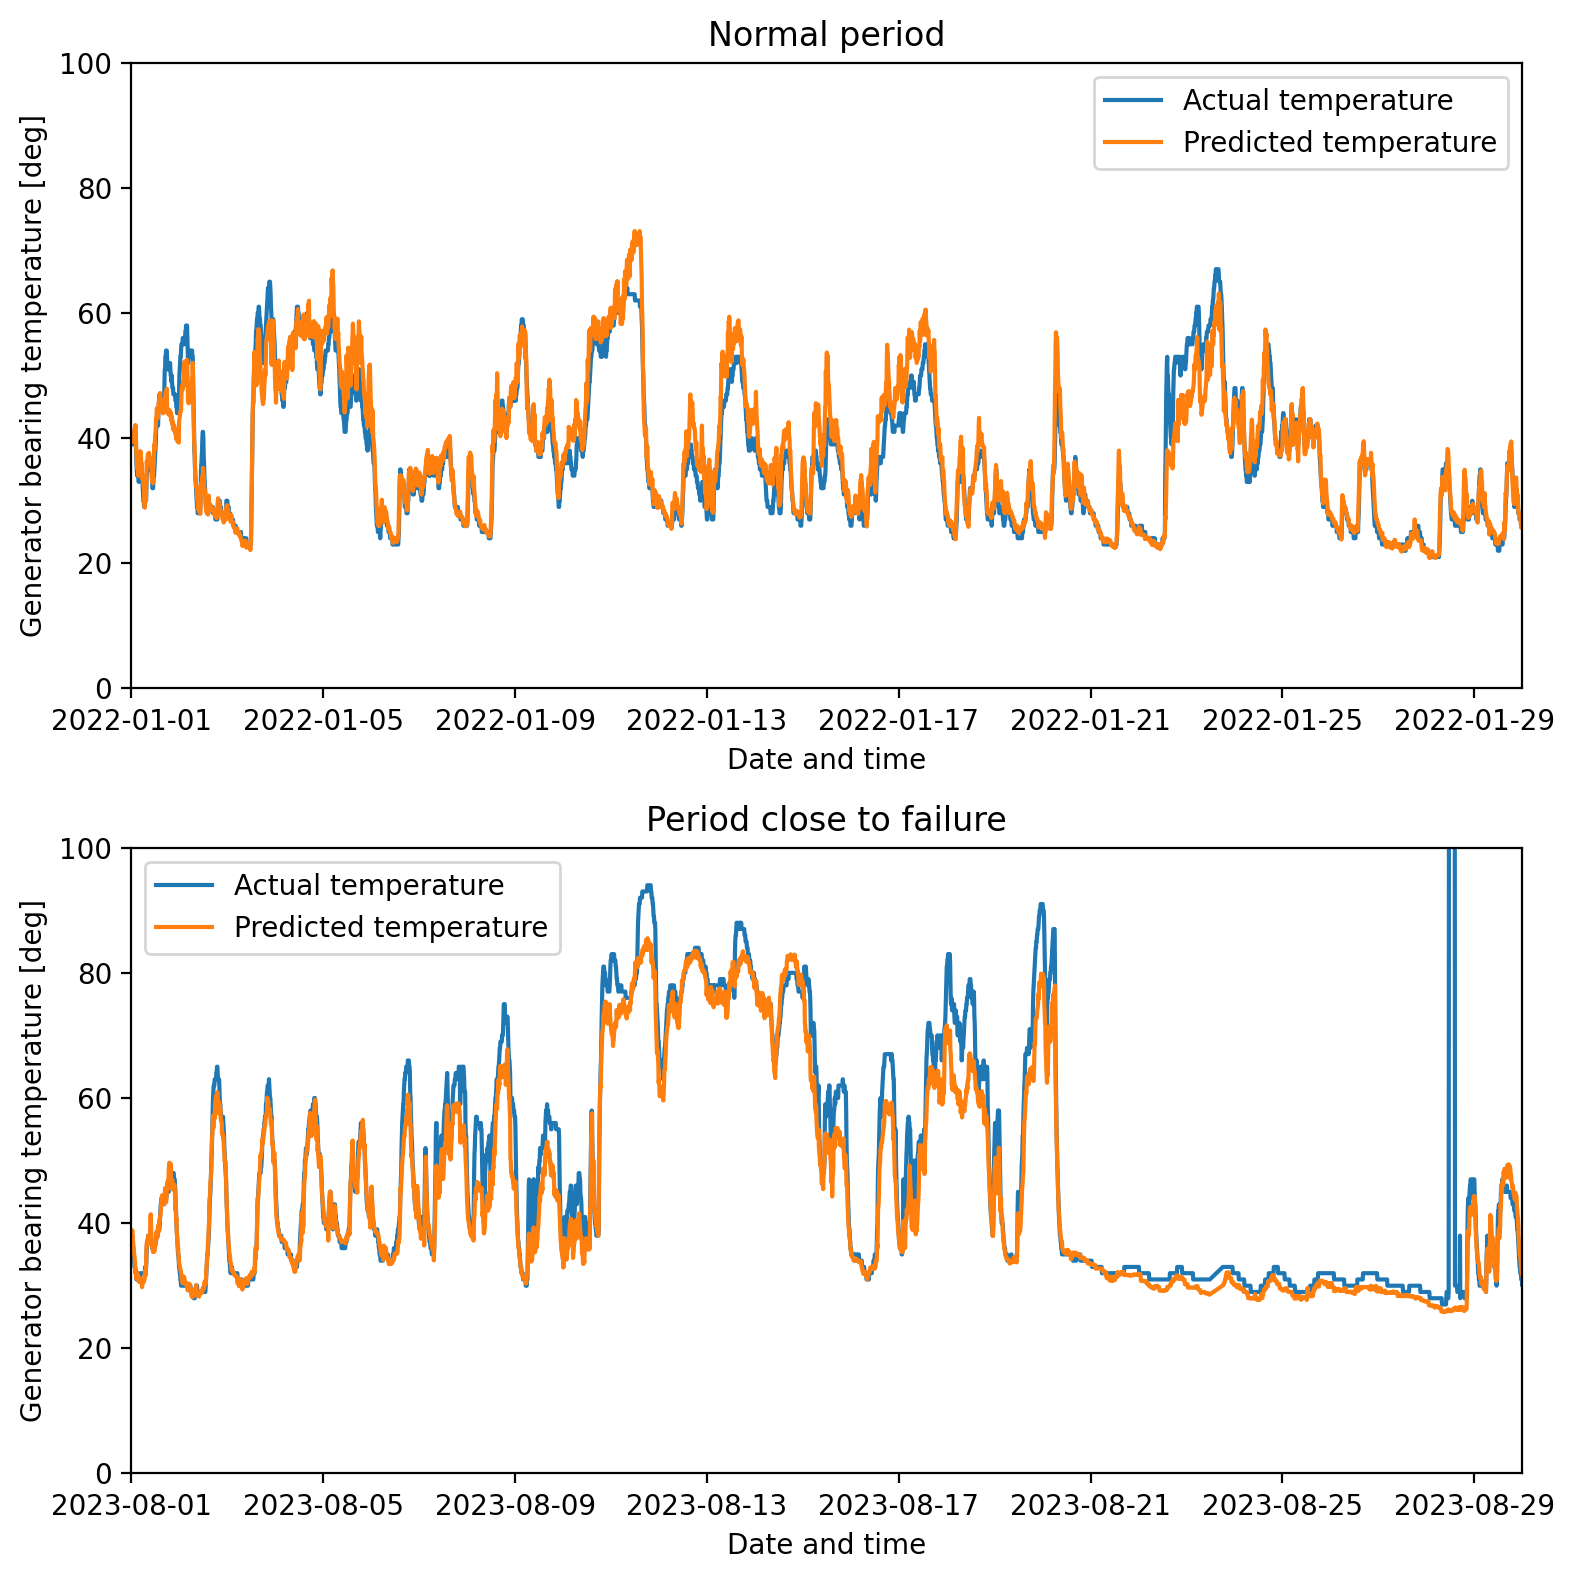

In [70]:
fig6,ax6 = plt.subplots(2,1,figsize = (8,8), dpi = 200)
ax6[0].plot(iData['time_stamp'],iData['Temperature in generator bearing 2 (Drive End)_avg'],label = 'Actual temperature')
ax6[0].plot(iData['time_stamp'],iData['NBM_B2_temp'], label = 'Predicted temperature')
ax6[0].set_xlim(pd.to_datetime(['2022-01-01','2022-01-30']))
ax6[0].set_ylim([0,100])
ax6[0].set_xlabel('Date and time')
ax6[0].set_ylabel('Generator bearing temperature [deg]')
ax6[0].legend()
ax6[0].set_title('Normal period')
ax6[1].plot(iData['time_stamp'],iData['Temperature in generator bearing 2 (Drive End)_avg'],label = 'Actual temperature')
ax6[1].plot(iData['time_stamp'],iData['NBM_B2_temp'], label = 'Predicted temperature')
ax6[1].set_xlim(pd.to_datetime(['2023-08-01','2023-08-30']))
ax6[1].set_ylim([0,100])
ax6[1].set_xlabel('Date and time')
ax6[1].set_ylabel('Generator bearing temperature [deg]')
ax6[1].legend()
ax6[1].set_title('Period close to failure')
plt.tight_layout()
plt.show()

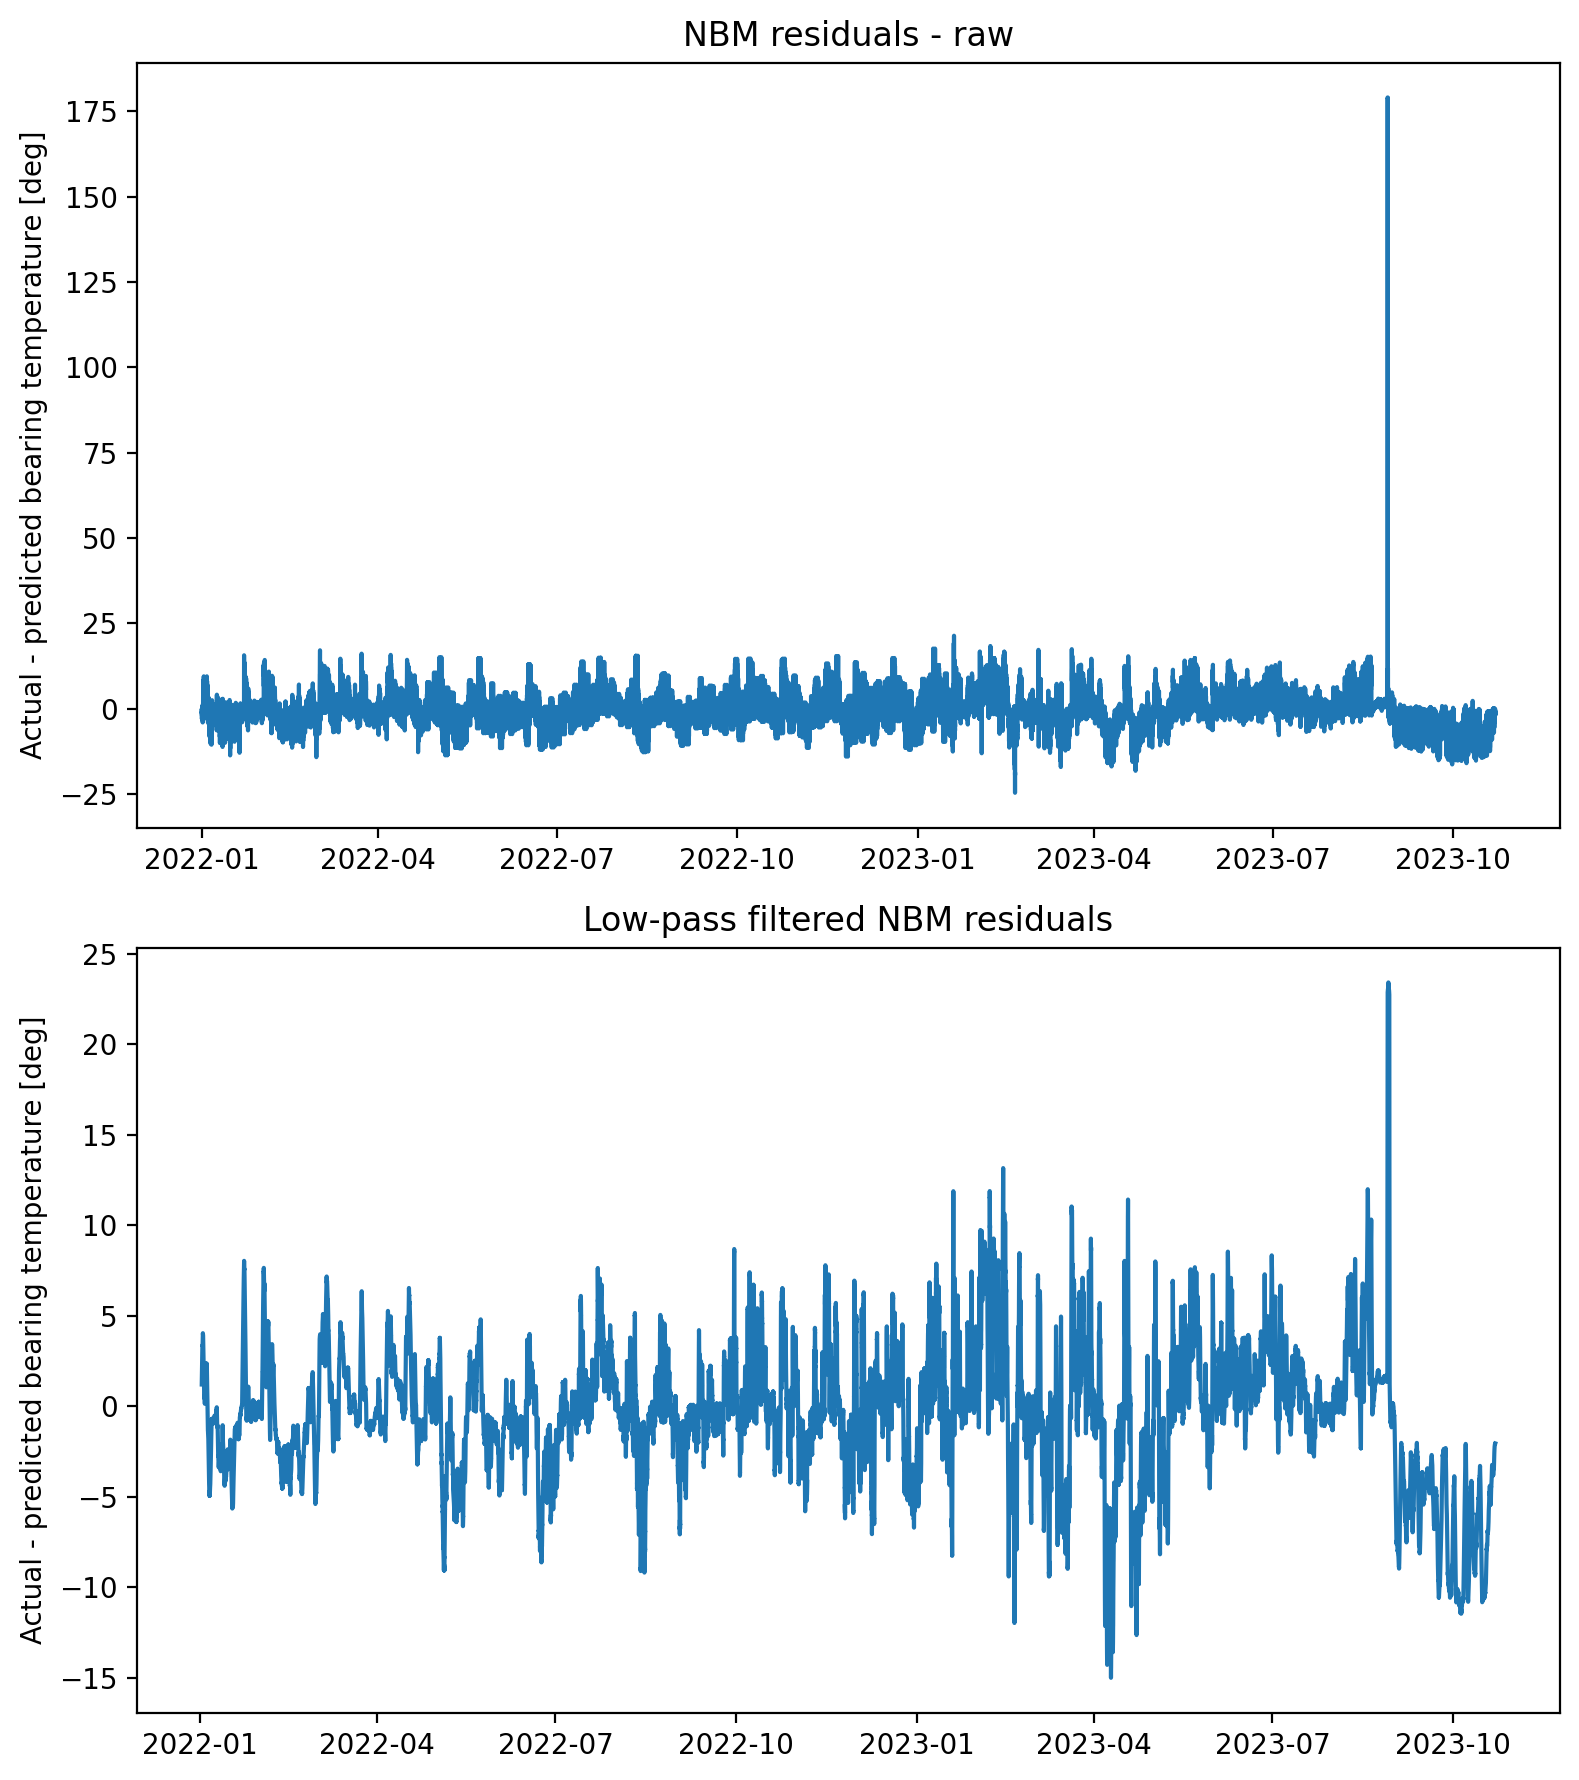

In [74]:
# PLOT RESIDUALS

fig7,ax7 = plt.subplots(2,1,figsize = (8,9),dpi = 200)
ax7[0].plot(iData.loc[:,'time_stamp'],-iData.loc[:,'NBM_B2_temp_residual'], label = 'Residuals')
ax7[0].set_title('NBM residuals - raw')
ax7[0].set_ylabel('Actual - predicted bearing temperature [deg]')
ax7[1].plot(iData.loc[NBMinputvalidB2,'time_stamp'],-iData.loc[NBMinputvalidB2,'NBM_B2_temp_residual'].rolling(24*6).mean(), label = '1-day rolling window')
ax7[1].set_title('Low-pass filtered NBM residuals')
ax7[1].set_ylabel('Actual - predicted bearing temperature [deg]')
plt.tight_layout()

We can now continue with training the other models - for Bearing 1, and for the difference between bearing 1 and bearing 2 temperatures

In [75]:
TrainingPeriodStartB1 = '2023-01-01 00:00:00'
TrainingPeriodEndB1 = '2024-01-01 00:00:00'
TestPeriodStartB1 = '2022-01-01 00:00:00'
TestPeriodEndB1 = '2023-01-01 00:00:00'
TrainingPeriodB1 = (iData['time_stamp'] >= TrainingPeriodStartB1) & (iData['time_stamp'] < TrainingPeriodEndB1)
TestingPeriodB1 = (iData['time_stamp'] >= TestPeriodStartB1) & (iData['time_stamp'] < TestPeriodEndB1)

TrainingPeriodStartB0 = '2022-07-01 00:00:00'
TrainingPeriodEndB0 = '2023-06-01 00:00:00'
TestPeriodStartB0 = '2023-06-01 00:00:00'
TestPeriodEndB0 = '2024-01-01 00:00:00'
TrainingPeriodB0 = (iData['time_stamp'] >= TrainingPeriodStartB0) & (iData['time_stamp'] < TrainingPeriodEndB0)
TestingPeriodB0 = (iData['time_stamp'] >= TestPeriodStartB0) & (iData['time_stamp'] < TestPeriodEndB0)


InputFeatures_B1Final = InputFeatures_B2.copy()
InputFeatures_B1Final[0] = 'Temperature in generator bearing 2 (Drive End)_avg'
TargetFeatures_B1 = 'Temperature in generator bearing 1 (Non-Drive End)_avg'
iData['Tdifference'] = iData['Temperature in generator bearing 1 (Non-Drive End)_avg'] - iData['Temperature in generator bearing 2 (Drive End)_avg']
InputFeatures_B0Final = [InputFeatures_B2[i] for i in range(1,len(InputFeatures_B2))]
TargetFeatures_B0 = 'Tdifference'

NaNindexB1 = (iData[InputFeatures_B1Final].isna().sum(axis = 1) == 0) & (iData[TargetFeatures_B1].isna() == False)
NaNindexB0 = (iData[InputFeatures_B0Final].isna().sum(axis = 1) == 0) & (iData[TargetFeatures_B0].isna() == False)


In [76]:
XscalerB1Final = sklearn.preprocessing.StandardScaler()
XscalerB1Final.fit(iData[InputFeatures_B1Final])
YscalerB1Final = sklearn.preprocessing.StandardScaler()
YscalerB1Final.fit(iData[[TargetFeatures_B1]])

XtrainB1Final = XscalerB1Final.transform(iData.loc[(TrainingPeriodB1 & NaNindexB1),InputFeatures_B1Final])
XtestB1Final = XscalerB1Final.transform(iData.loc[(TestingPeriodB1 & NaNindexB1),InputFeatures_B1Final])

YtrainB1Final = YscalerB1Final.transform(iData.loc[(TrainingPeriodB1 & NaNindexB1),[TargetFeatures_B1]]) # Extra brackets on Target Features needed because it is a 1-D array
YtestB1Final = YscalerB1Final.transform(iData.loc[(TestingPeriodB1 & NaNindexB1),[TargetFeatures_B1]])

XscalerB0Final = sklearn.preprocessing.StandardScaler()
XscalerB0Final.fit(iData[InputFeatures_B0Final])
YscalerB0Final = sklearn.preprocessing.StandardScaler()
YscalerB0Final.fit(iData[[TargetFeatures_B0]])

XtrainB0Final = XscalerB0Final.transform(iData.loc[(TrainingPeriodB0 & NaNindexB0),InputFeatures_B0Final])
XtestB0Final = XscalerB0Final.transform(iData.loc[(TestingPeriodB0 & NaNindexB0),InputFeatures_B0Final])

YtrainB0Final = YscalerB0Final.transform(iData.loc[(TrainingPeriodB0 & NaNindexB0),[TargetFeatures_B0]]) # Extra brackets on Target Features needed because it is a 1-D array
YtestB0Final = YscalerB0Final.transform(iData.loc[(TestingPeriodB0 & NaNindexB0),[TargetFeatures_B0]])

In [77]:
ANN_B1 = sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(40,40),activation = 'relu')
ANN_B1.fit(XtrainB1Final,YtrainB1Final.ravel())
print(ANN_B1.score(XtestB1Final,YtestB1Final))

ANN_B0 = sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(40,40),activation = 'relu')
ANN_B0.fit(XtrainB0Final,YtrainB0Final.ravel())
print(ANN_B0.score(XtestB0Final,YtestB0Final))


0.984368746234295
-0.09651564798074896


/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [78]:
# EVALUATE THE NBM OVER THE ENTIRE DATASET (FOR "POWER OK" STATUS)

NBMinputvalidB1 = iData[InputFeatures_B1Final].isna().sum(axis = 1)==0

NBM_B1_temp = YscalerB1Final.inverse_transform(ANN_B1.predict(XscalerB1Final.transform(iData.loc[NBMinputvalidB1,InputFeatures_B1Final])).reshape(-1, 1))
#NBMpower[NBMpower < 0] = 0

iData["NBM_B1_temp"] = np.nan
iData.loc[NBMinputvalidB1,"NBM_B1_temp"] = NBM_B1_temp
NBM_B1_residuals = iData.loc[NBMinputvalidB1,"NBM_B1_temp"] - iData.loc[NBMinputvalidB1,'Temperature in generator bearing 1 (Non-Drive End)_avg']

iData["NBM_B1_temp_residual"] = 0.0
iData.loc[NBMinputvalidB1,"NBM_B1_temp_residual"] = NBM_B1_residuals

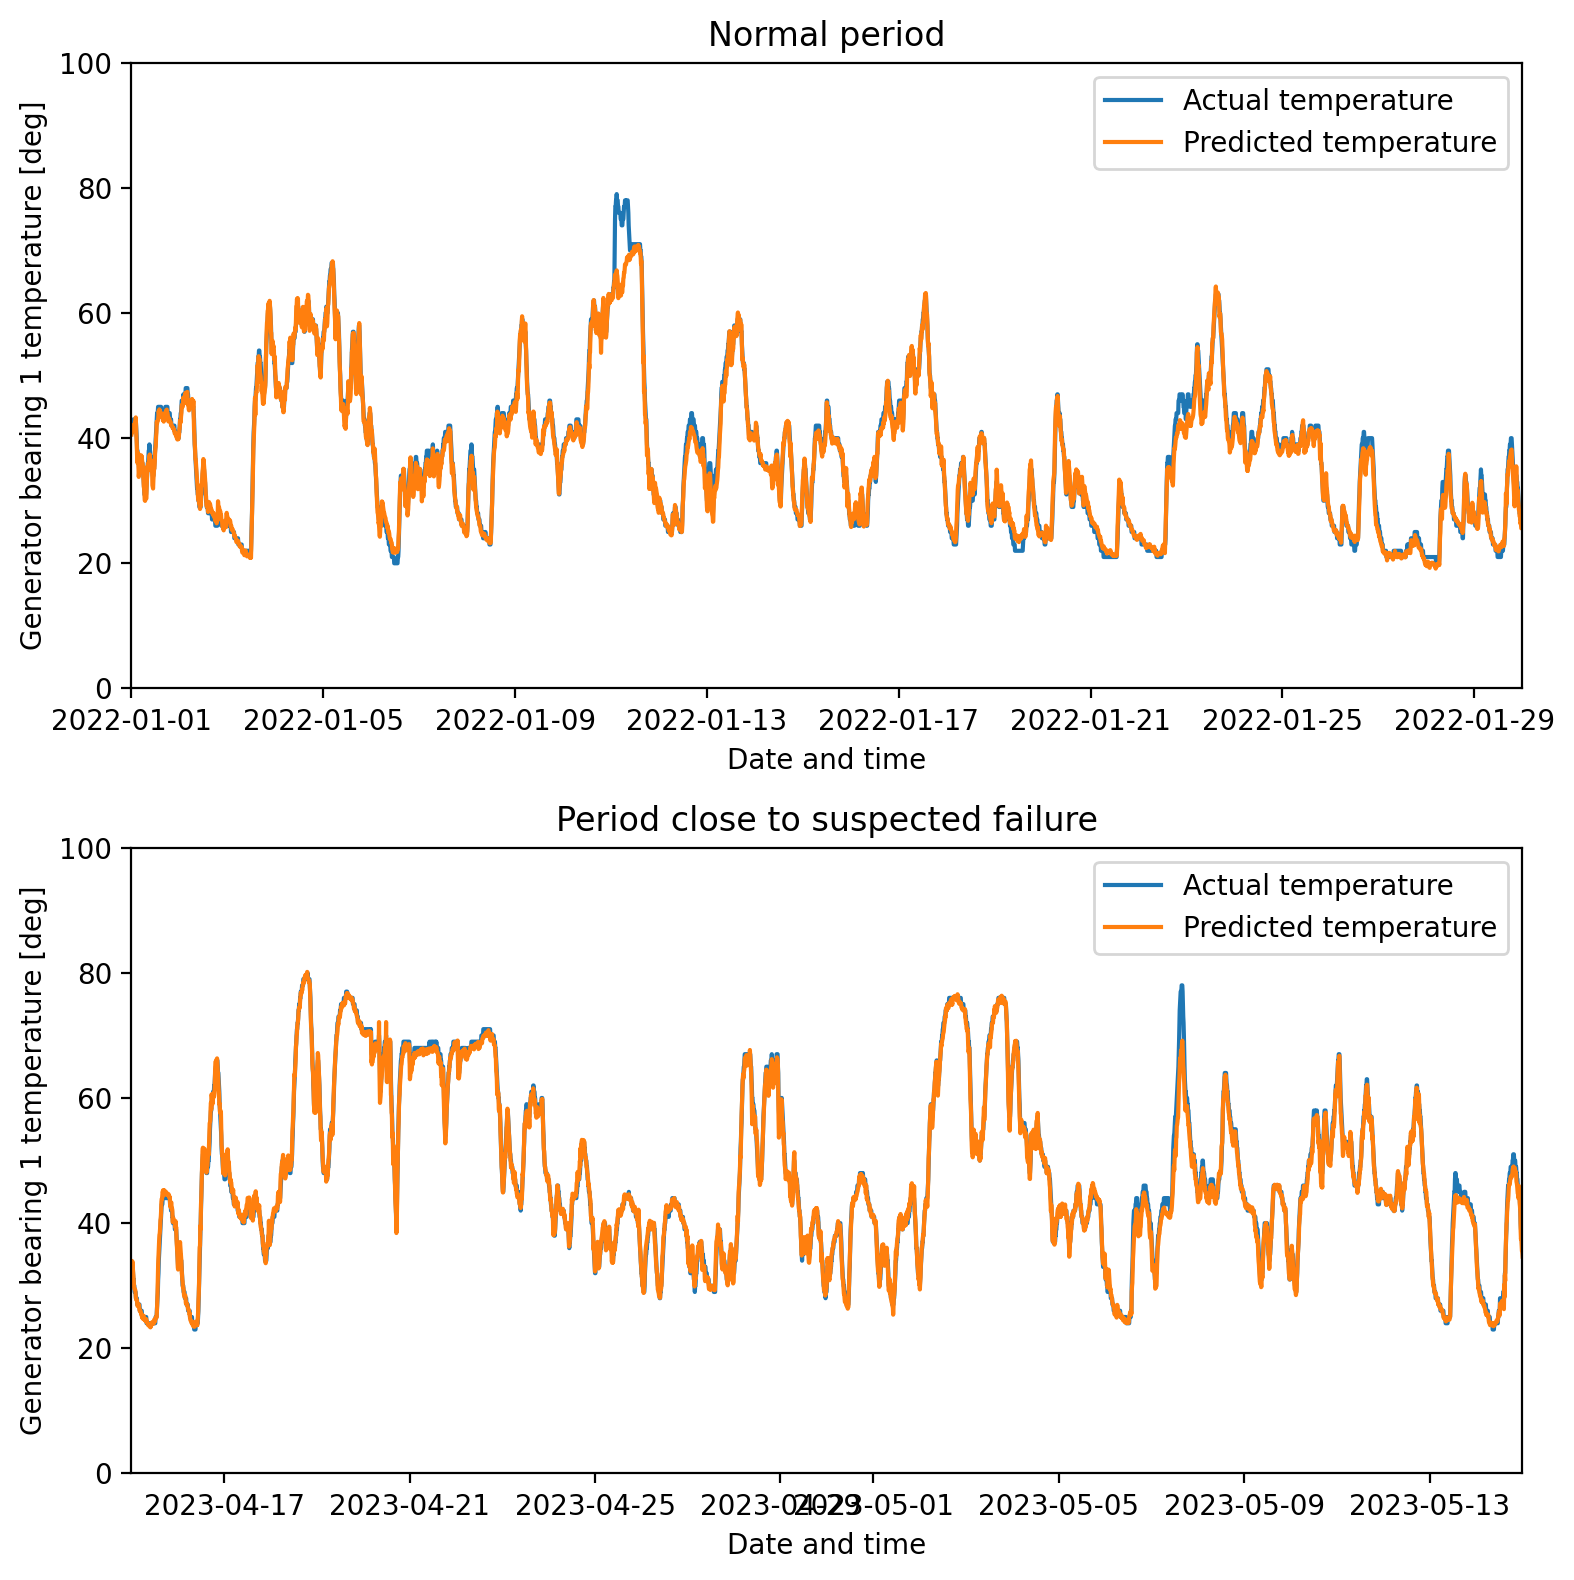

In [79]:
fig8,ax8 = plt.subplots(2,1,figsize = (8,8), dpi = 200)
ax8[0].plot(iData['time_stamp'],iData['Temperature in generator bearing 1 (Non-Drive End)_avg'],label = 'Actual temperature')
ax8[0].plot(iData['time_stamp'],iData['NBM_B1_temp'], label = 'Predicted temperature')
ax8[0].set_xlim(pd.to_datetime(['2022-01-01','2022-01-30']))
ax8[0].set_ylim([0,100])
ax8[0].set_xlabel('Date and time')
ax8[0].set_ylabel('Generator bearing 1 temperature [deg]')
ax8[0].legend()
ax8[0].set_title('Normal period')
ax8[1].plot(iData['time_stamp'],iData['Temperature in generator bearing 1 (Non-Drive End)_avg'],label = 'Actual temperature')
ax8[1].plot(iData['time_stamp'],iData['NBM_B1_temp'], label = 'Predicted temperature')
ax8[1].set_xlim(pd.to_datetime(['2023-04-15','2023-05-15']))
ax8[1].set_ylim([0,100])
ax8[1].set_xlabel('Date and time')
ax8[1].set_ylabel('Generator bearing 1 temperature [deg]')
ax8[1].legend()
ax8[1].set_title('Period close to suspected failure')
plt.tight_layout()
plt.show()

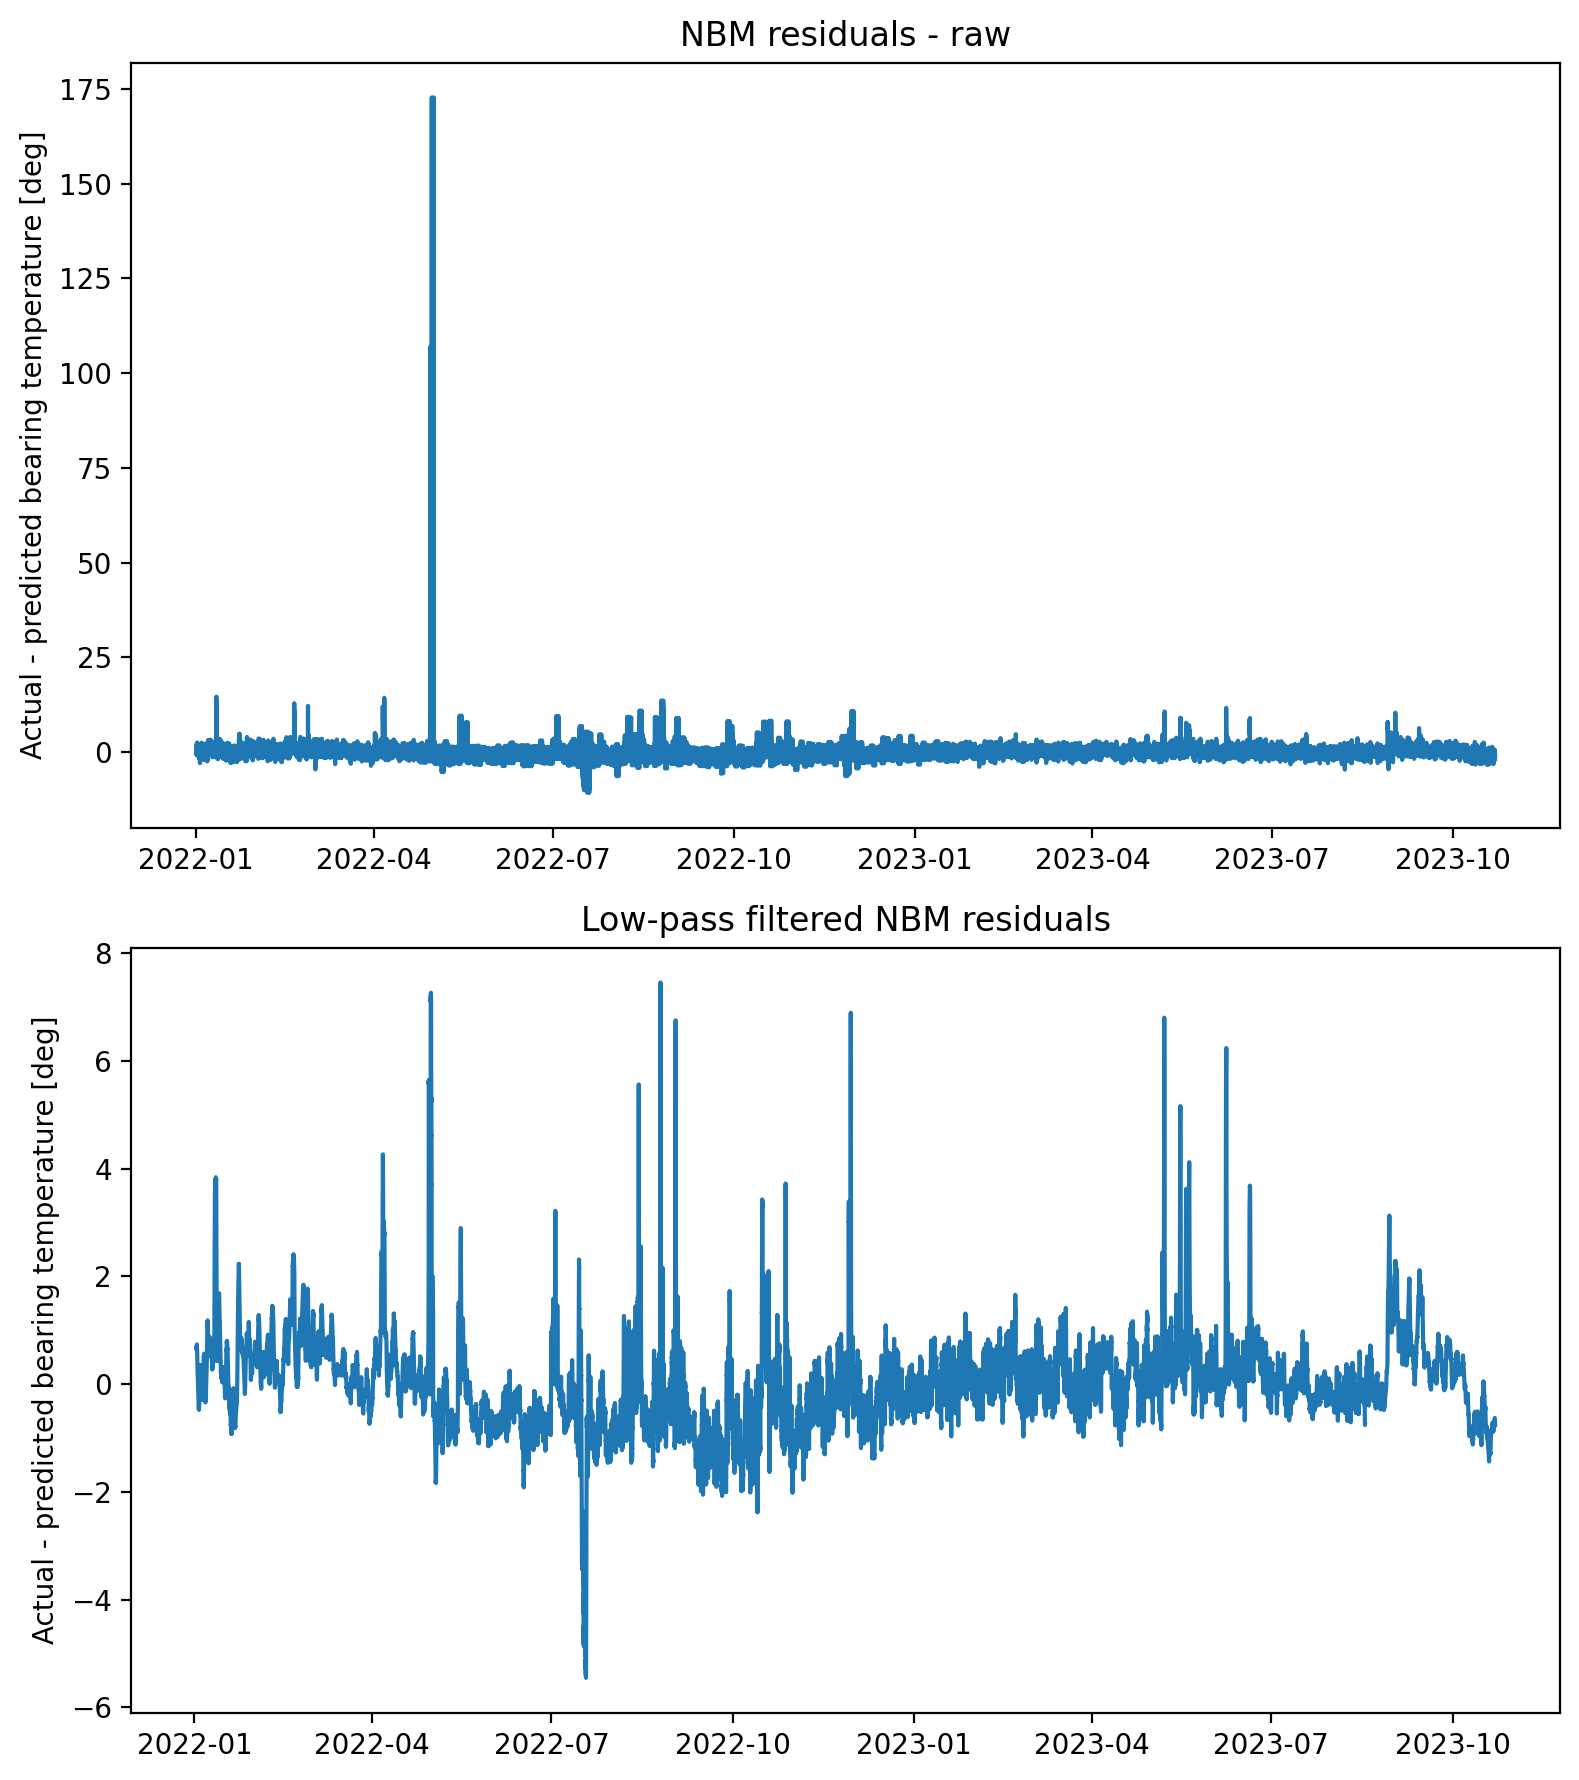

In [80]:
# PLOT RESIDUALS

fig9,ax9 = plt.subplots(2,1,figsize = (8,9),dpi = 200)
ax9[0].plot(iData.loc[:,'time_stamp'],-iData.loc[:,'NBM_B1_temp_residual'], label = 'Residuals')
ax9[0].set_title('NBM residuals - raw')
ax9[0].set_ylabel('Actual - predicted bearing temperature [deg]')
ax9[1].plot(iData.loc[NBMinputvalidB1,'time_stamp'],-iData.loc[NBMinputvalidB1,'NBM_B1_temp_residual'].rolling(24*6).mean(), label = '1-day rolling window')
ax9[1].set_title('Low-pass filtered NBM residuals')
ax9[1].set_ylabel('Actual - predicted bearing temperature [deg]')
plt.tight_layout()